# Context

Churn dataset contains client information of a classified bank, located in Russian Federation. Thus, some features might not be well formatted. More specifically, marital_status, job_position, tariff_id, region are labeled and not categorized. Data source obtained from [Kaggle](https://www.kaggle.com/datasets/ilya2raev/bank-churn-dataset).

# Objective

To perform: 
- Logistic regression modelling
- Nonlinear modeling with XGBoost
- Lift analysis
- Profit optimization

# Data Description

- gender: Male or Female
- age: Age in years
- marital_status: Uncategorized martial status
- job_position: Uncategorized job position
- credit_sum: Sum of a credit
- credit_length: Loan term
- scoring: Internal bank scoring
- education: Education level
- tariff_id: Current banking tariff (uncategorized)
- region: Client region residence
- average_region_wage: Average monthly region wage (RUB)
- income: Monthly income (RUB)
- credit_count: Number of credits client is currently having
- overdue_count: Number of overdue loans
- churn: Target value


# Libraries and functions required

## Libraries

In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores and split data
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    make_scorer,
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold, 
    cross_val_score,
    GridSearchCV,
)


# To impute missing values
from sklearn.impute import SimpleImputer


# To build models
import statsmodels.stats.api as sms
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)
# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)    
# setting the precision of floating numbers to 2 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Functions

### Plots

In [2]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [3]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [4]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [5]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Modelling

In [6]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target, threshold=0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold value
    """

    # predicting using the independent variables
    pred_temp = model.predict_proba(predictors)[:,1] > threshold
    pred = np.round(pred_temp)
    
    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [7]:
def confusion_matrix_sklearn(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold value
    """
    y_pred_temp = model.predict_proba(predictors)[:,1] > threshold
    y_pred = np.round(y_pred_temp)
    
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [8]:
def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

# Load data

In [9]:
data = pd.read_csv("Churn.csv")
df = data.copy()

# Analysis

## Data Overview

In [10]:
df.head()

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn
0,Female,48,3.00,15,59998.00,10,0.77,2.00,28,23.00,25850.00,30000.00,1.00,1.00,0
1,Male,28,NaN,15,10889.00,6,0.25,2.00,2,30.00,66880.00,43000.00,2.00,0.00,0
2,Female,32,3.00,14,10728.00,12,0.46,4.00,2,64.00,23430.00,23000.00,5.00,0.00,0
3,Male,27,2.00,14,12009.09,12,0.36,2.00,2,8.00,23650.00,17000.00,2.00,0.00,0
4,Female,45,3.00,14,16908.89,10,0.42,4.00,2,77.00,26620.00,NaN,1.00,0.00,0


In [11]:
df.shape

(170744, 15)

In [12]:
df.duplicated().sum()

np.int64(1151)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(169593, 15)

In [15]:
df.isnull().sum()

gender                    0
age                       0
marital_status            5
job_position              0
credit_sum                1
credit_length             0
scoring                   3
education                 3
tariff_id                 0
region                  189
average_region_wage     189
income                    2
credit_count           9190
overdue_count          9190
churn                     0
dtype: int64

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,169593.00,36.50,10.55,18.00,28.00,34.00,43.00,71.00
marital_status,169588.00,3.20,0.74,1.00,3.00,3.00,4.00,5.00
job_position,169593.00,13.16,3.13,1.00,14.00,14.00,14.00,18.00
credit_sum,169592.00,26077.63,16227.07,2736.00,14907.95,21220.00,32028.00,200000.00
credit_length,169593.00,10.98,3.54,3.00,10.00,10.00,12.00,36.00
scoring,169590.00,0.47,0.12,0.00,0.38,0.46,0.55,1.13
education,169590.00,3.20,1.06,1.00,2.00,4.00,4.00,5.00
tariff_id,169593.00,14.12,11.54,1.00,2.00,19.00,28.00,33.00
region,169404.00,43.01,22.22,1.00,25.00,40.00,63.00,82.00
average_region_wage,169404.00,32962.28,12578.22,16830.00,25520.00,27390.00,42460.00,66880.00


- `Age` range is between 18 to 71 years old. With an average of 36 years old.
- 5 `marital_status`, average to be the at 3rd marital status category.
- 18 different `job_position`, looks like majority are at category 14.
- `credit_sum` capped at RUB 200,000 unit currency. On average customer credit sum is at RUB 26,077 unit currency.
- `credit_length` capped at 36 months, minimum of 3 months, averages at 10 months.
- `scoring` ranges between 0.12 to 1.128, averages at 0.46.
- 5 `education` level, majority is at category 4.
- `tariff_id` 33 different tariff ID.
- `region` total of 82.
- `average_region_wage` minimum of RUB 16,830 upto a maximum of RUB 66,880.
- `income` per month at a minimum of RUB 25,026 to a maximum of RUB 950,000, averages at RUB 40,125.
- `credit_count` the number of credits client is having ranges between 0 to 21. Average 2 credits per client.
- `overdue_count` at most 3 counts, but averaged at 0.

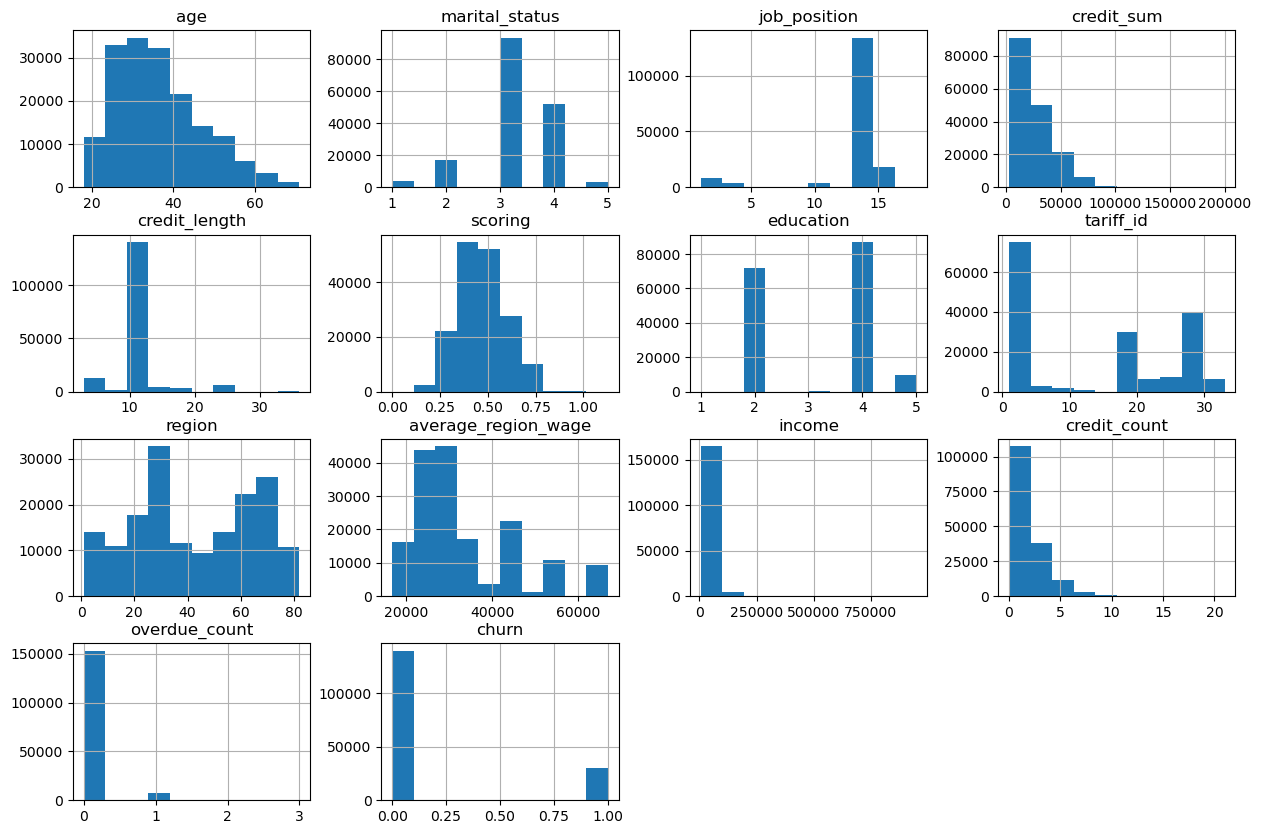

In [17]:
df.hist(figsize=(15,10))
plt.show()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169593 entries, 0 to 170743
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               169593 non-null  object 
 1   age                  169593 non-null  int64  
 2   marital_status       169588 non-null  float64
 3   job_position         169593 non-null  int64  
 4   credit_sum           169592 non-null  float64
 5   credit_length        169593 non-null  int64  
 6   scoring              169590 non-null  float64
 7   education            169590 non-null  float64
 8   tariff_id            169593 non-null  int64  
 9   region               169404 non-null  float64
 10  average_region_wage  169404 non-null  float64
 11  income               169591 non-null  float64
 12  credit_count         160403 non-null  float64
 13  overdue_count        160403 non-null  float64
 14  churn                169593 non-null  int64  
dtypes: float64(9), int64(5

In [19]:
convert_dict = {
    'marital_status': object,
    'job_position' : object,
    'education': object,
    'tariff_id': object,
    'region': object,
    'churn': object,
}

df = df.astype(convert_dict)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169593 entries, 0 to 170743
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               169593 non-null  object 
 1   age                  169593 non-null  int64  
 2   marital_status       169588 non-null  object 
 3   job_position         169593 non-null  object 
 4   credit_sum           169592 non-null  float64
 5   credit_length        169593 non-null  int64  
 6   scoring              169590 non-null  float64
 7   education            169590 non-null  object 
 8   tariff_id            169593 non-null  object 
 9   region               169404 non-null  object 
 10  average_region_wage  169404 non-null  float64
 11  income               169591 non-null  float64
 12  credit_count         160403 non-null  float64
 13  overdue_count        160403 non-null  float64
 14  churn                169593 non-null  object 
dtypes: float64(6), int64(2

In [20]:
cat_columns = df.describe(include=['object']).columns
cat_columns

for i in cat_columns:
    print("Unique values in", i, "are :")
    print(df[i].value_counts())
    print("-" * 50)

Unique values in gender are :
gender
Male      88097
Female    81496
Name: count, dtype: int64
--------------------------------------------------
Unique values in marital_status are :
marital_status
3.00    93306
4.00    51827
2.00    16836
1.00     4167
5.00     3452
Name: count, dtype: int64
--------------------------------------------------
Unique values in job_position are :
job_position
14    133711
15     17591
2       5549
10      4090
4       3727
1       2778
17       653
8        537
16       351
6        240
3        125
18       110
11        65
13        40
12        12
5          8
7          5
9          1
Name: count, dtype: int64
--------------------------------------------------
Unique values in education are :
education
4.00    86986
2.00    72046
5.00     9890
3.00      561
1.00      107
Name: count, dtype: int64
--------------------------------------------------
Unique values in tariff_id are :
tariff_id
2     68892
28    38764
19    15490
20    10880
25     7452
3

## Exploratory Analysis

### Univariate

In [21]:
num_columns = df.describe(include=np.number).columns
num_columns

Index(['age', 'credit_sum', 'credit_length', 'scoring', 'average_region_wage',
       'income', 'credit_count', 'overdue_count'],
      dtype='object')

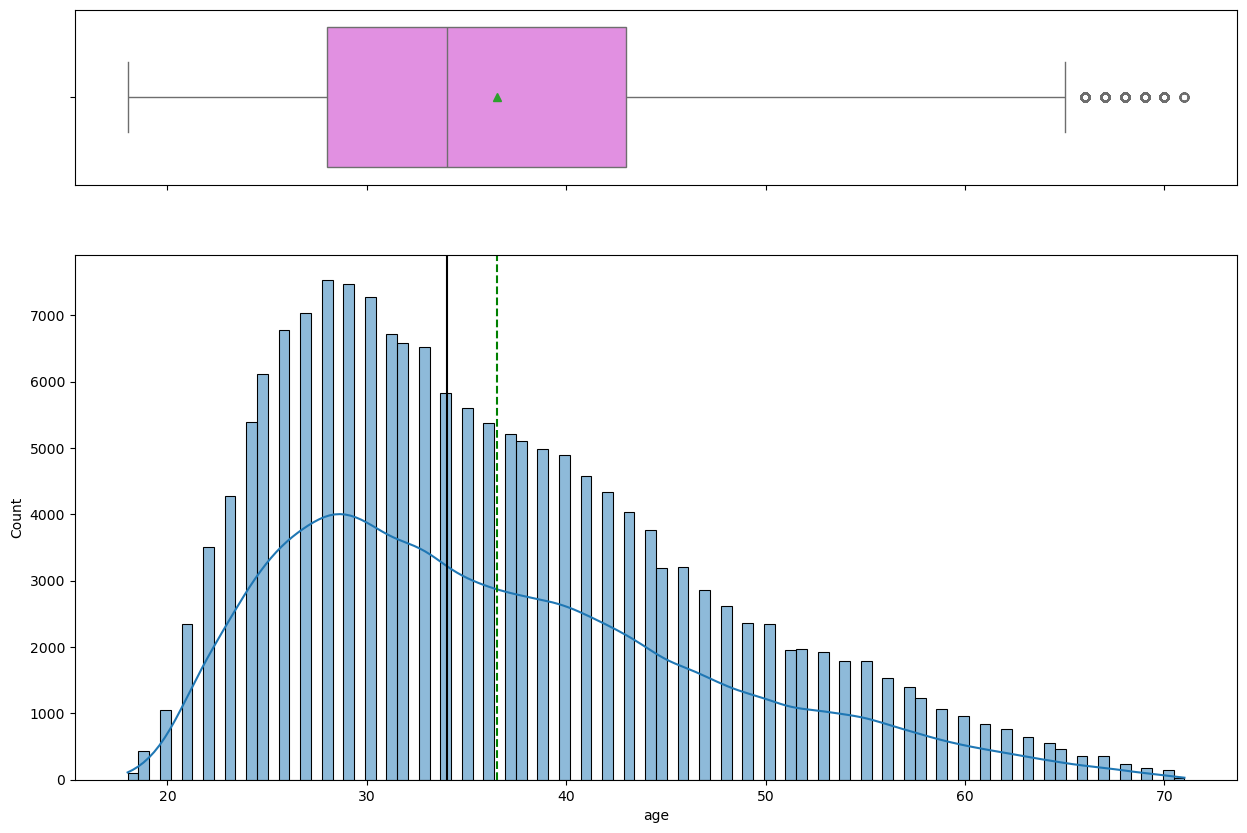

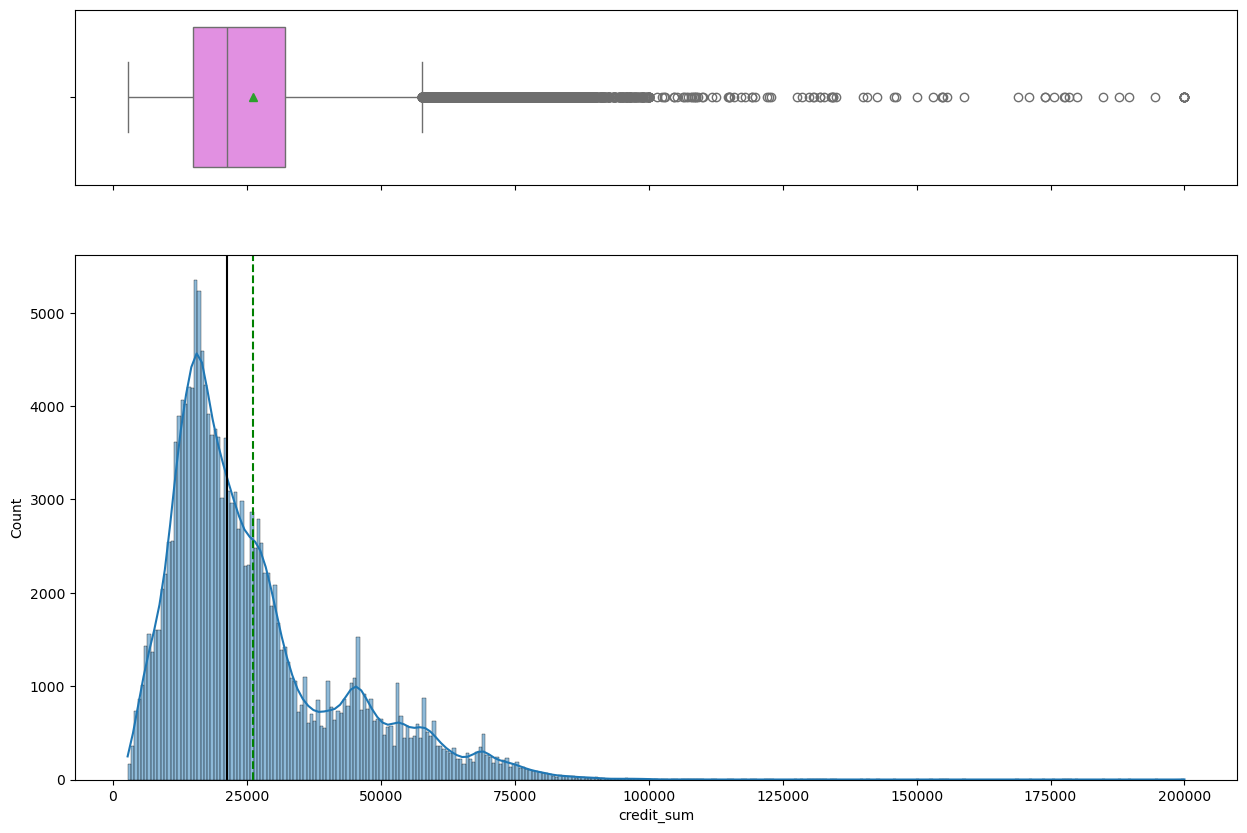

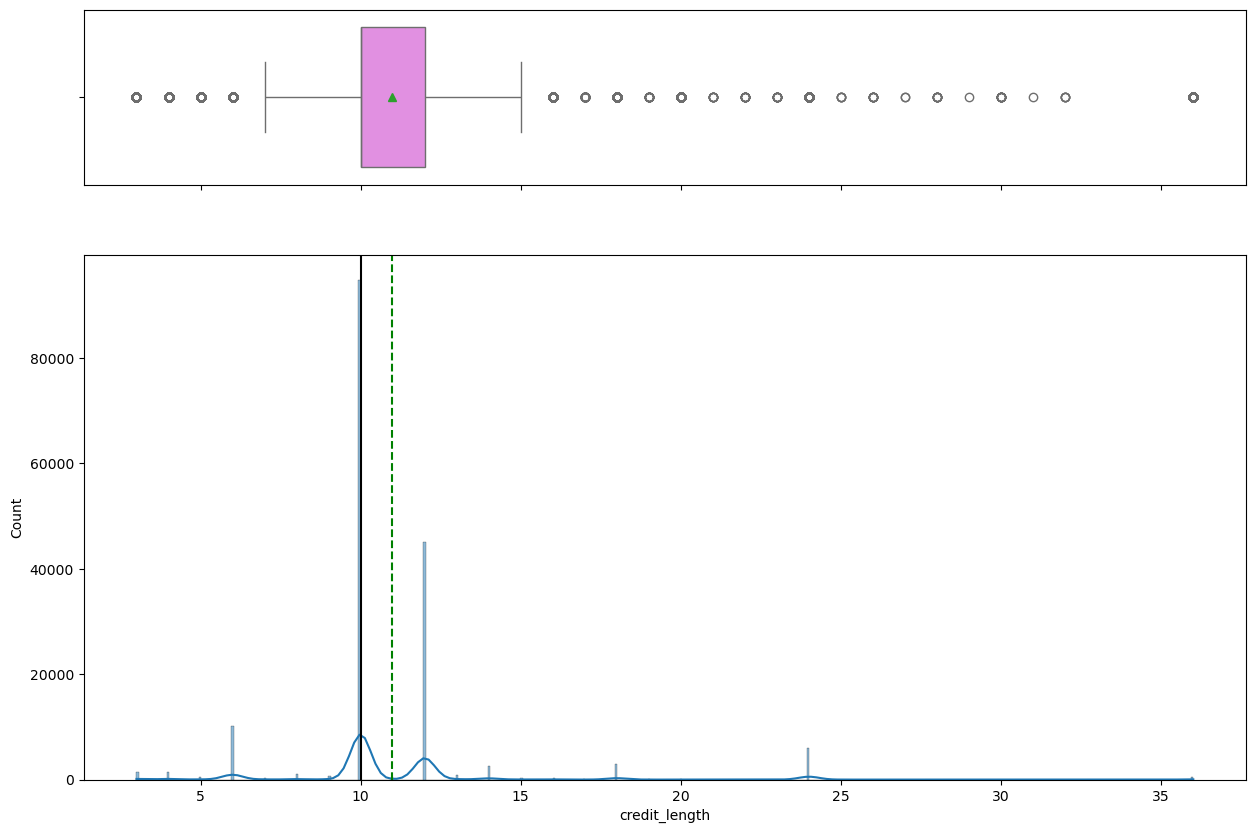

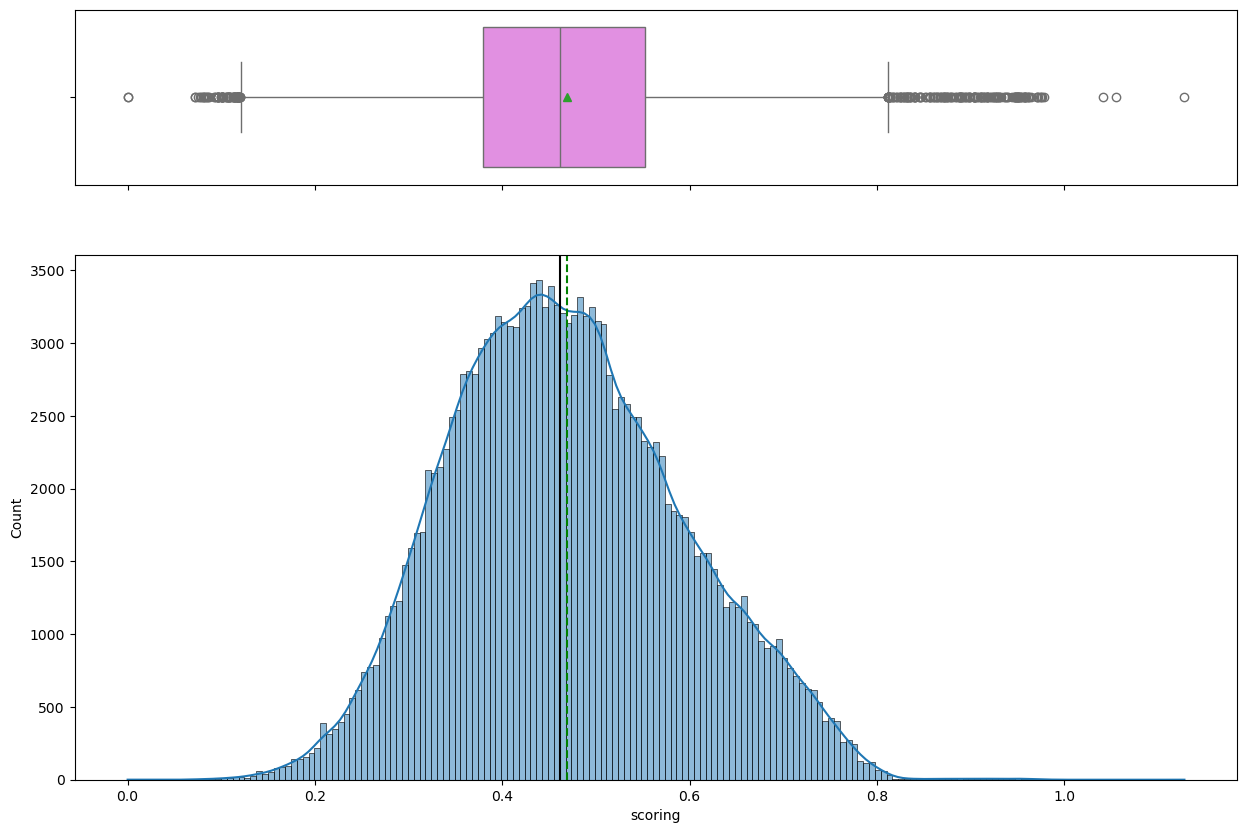

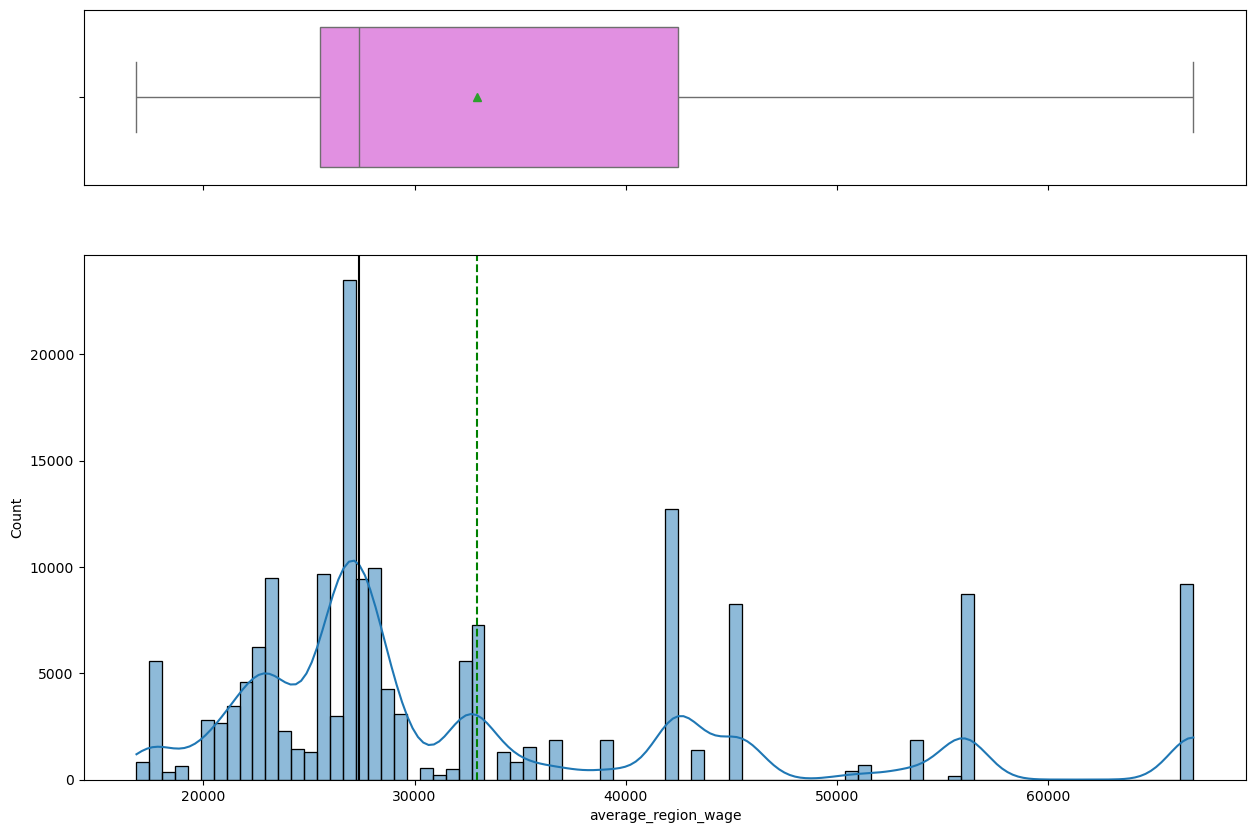

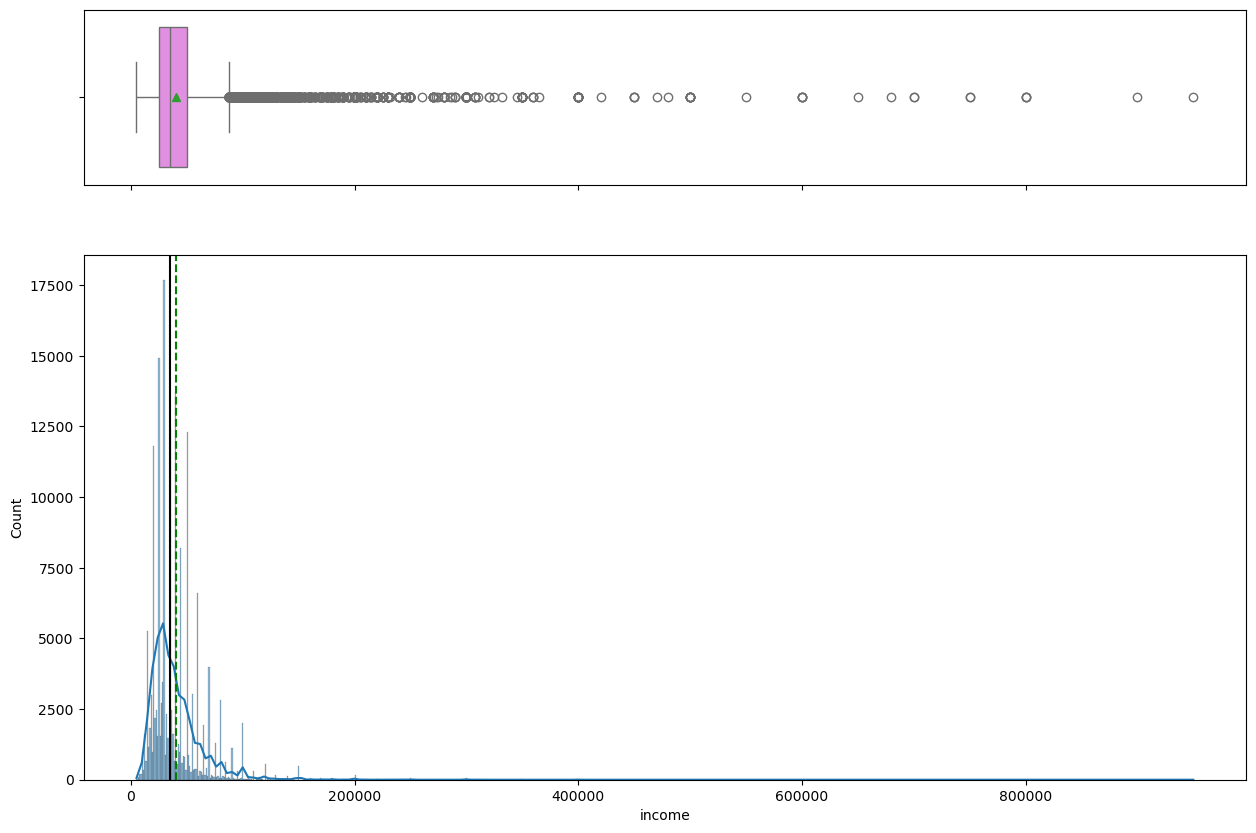

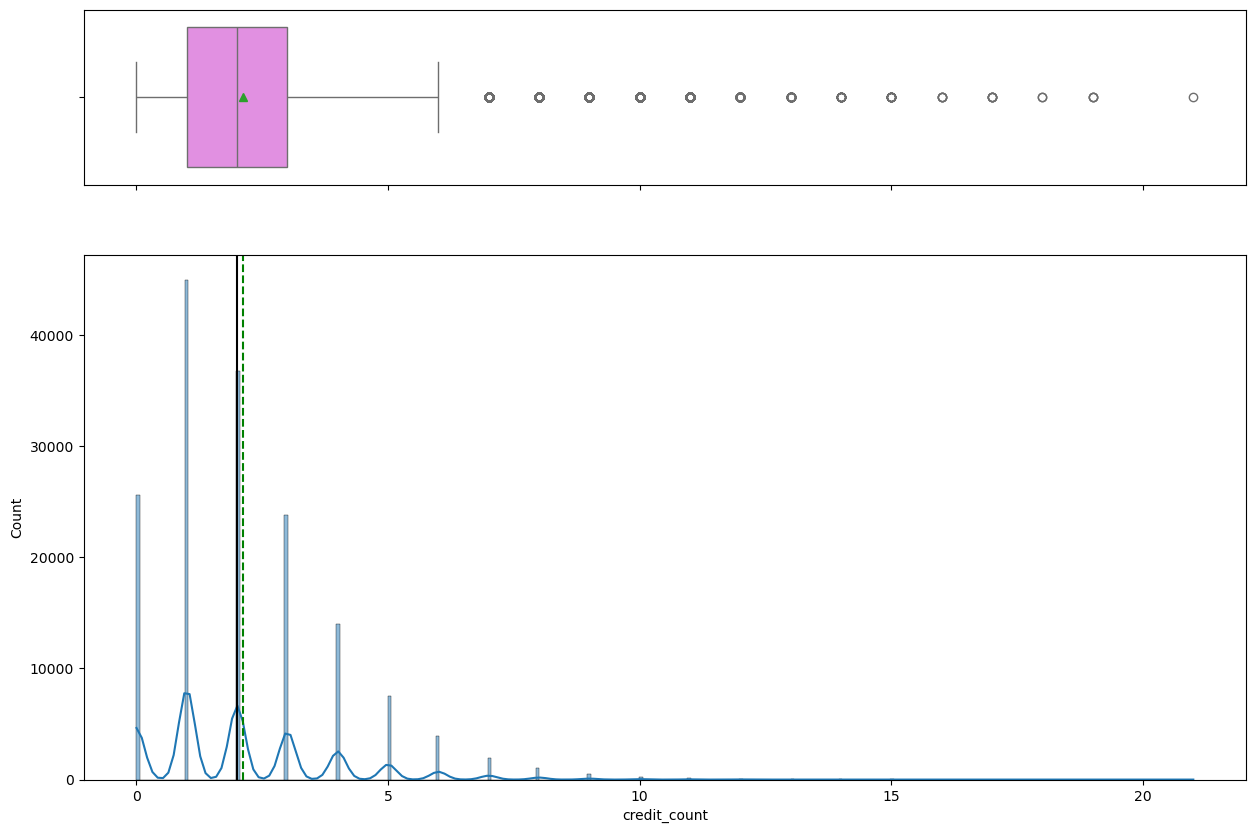

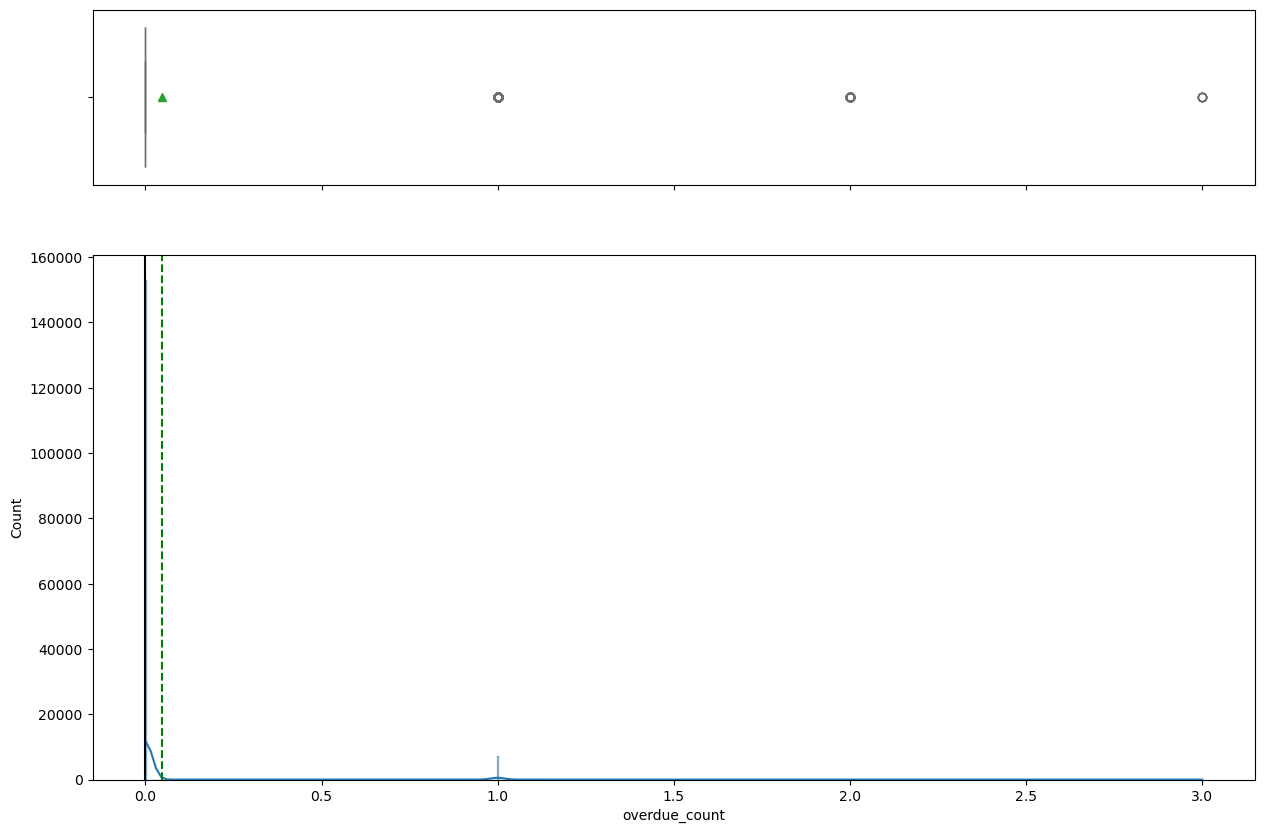

In [22]:
for i in num_columns:
    histogram_boxplot(df, i ,kde = True)

`Age`
-  Right-skewed, a common distritbution in age demographic.

`credit_sum`
- has severe outlier, heavily right-skewed.

`credit_length`
- has significant outlier too.

`scoring`
- Somewhat normally-distributed.

`average_region_wage`
- Has many peaks, possibly due to different region have their own unique distribution.

`income`
- Showing common distribution as expected, heavily skewed to the right.

`credit_count` and `overdue_count` 
- Shows no special behaviour.

We will inspect whether we will treat the outliers we have seen later.

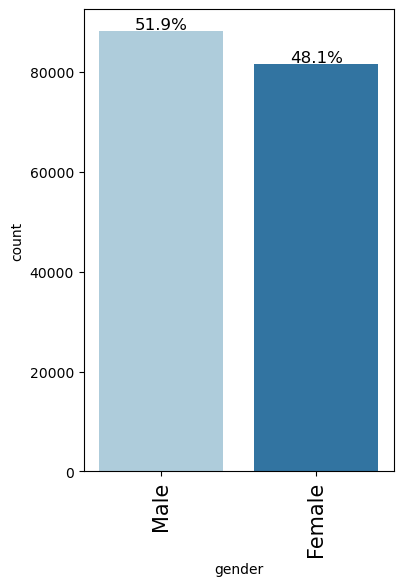

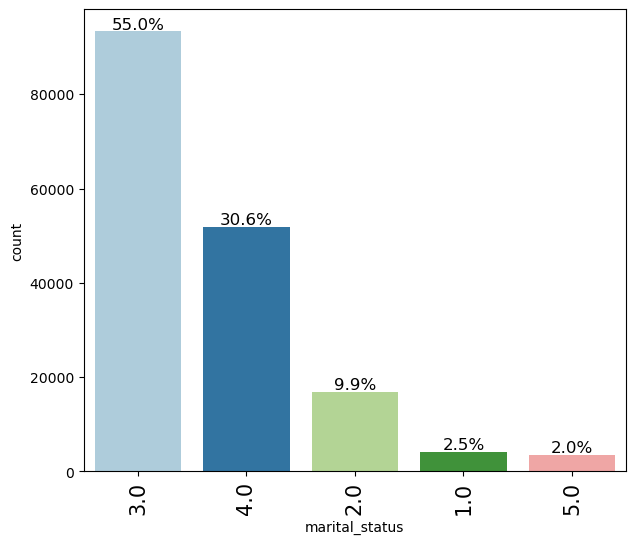

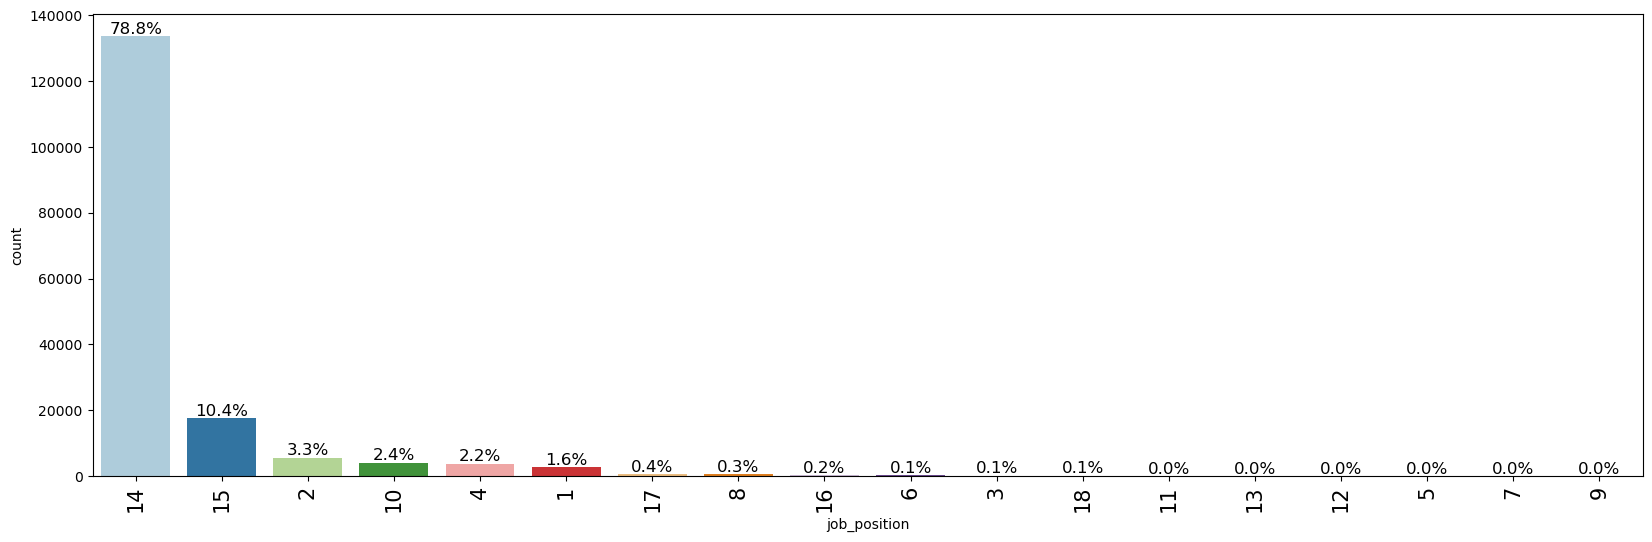

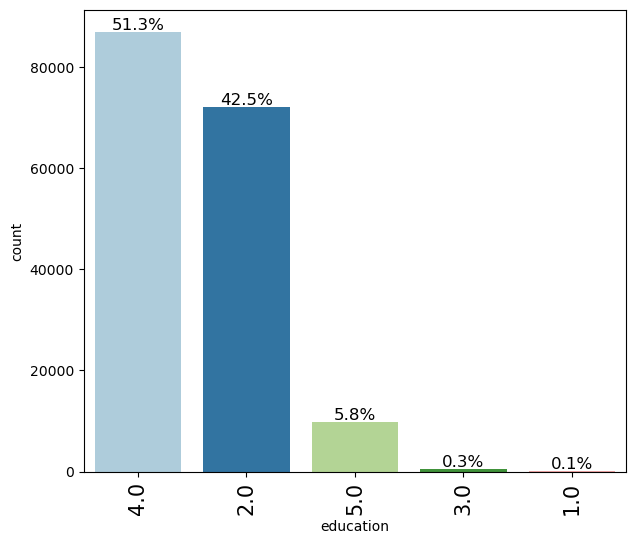

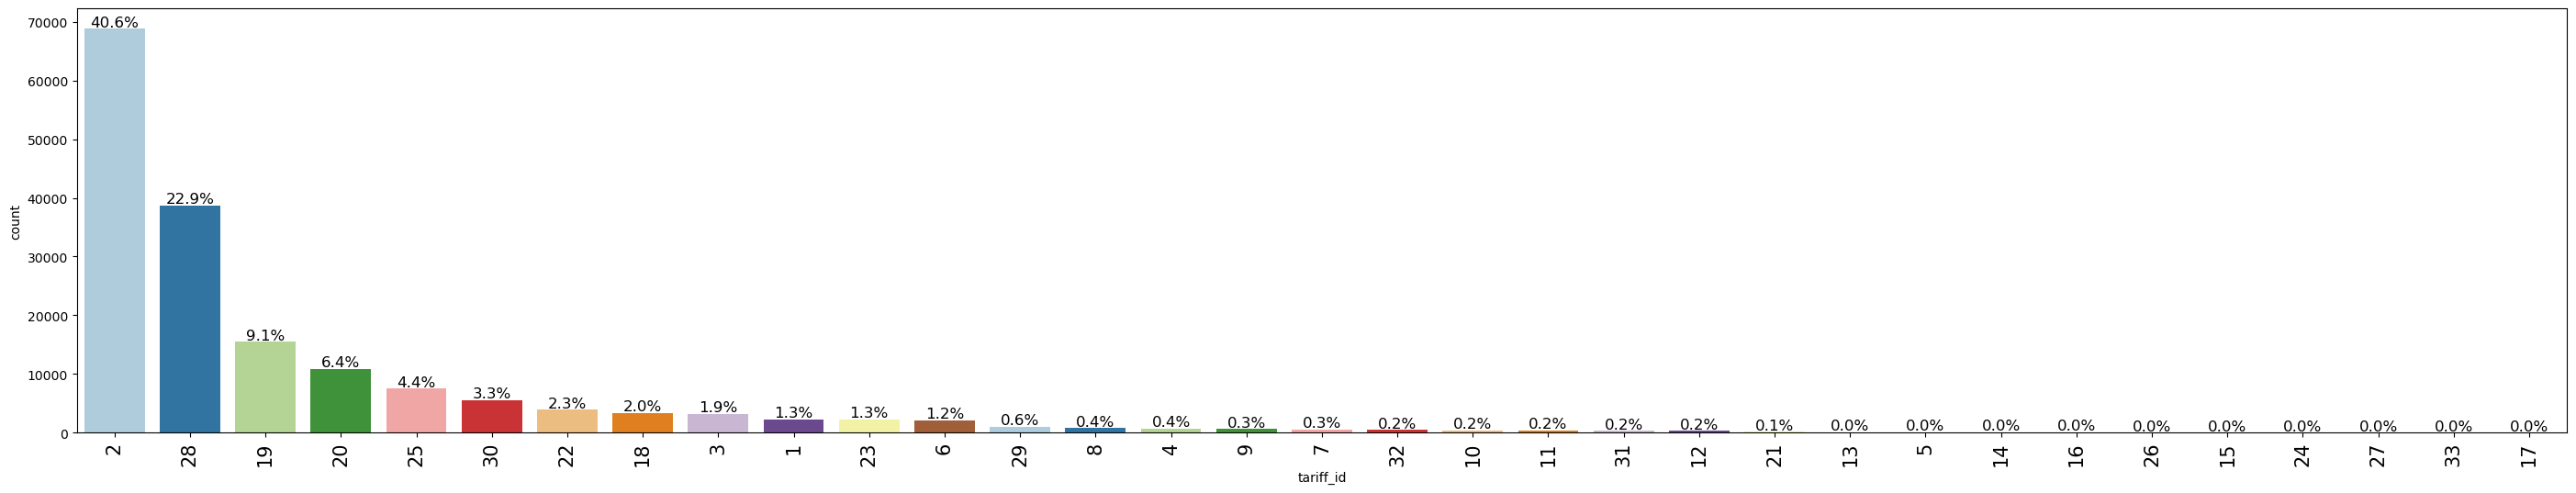

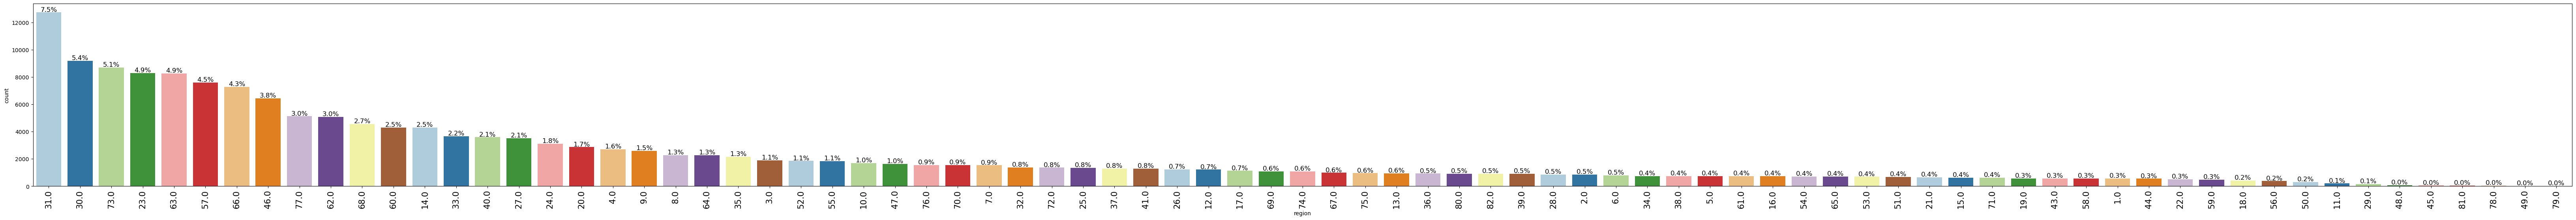

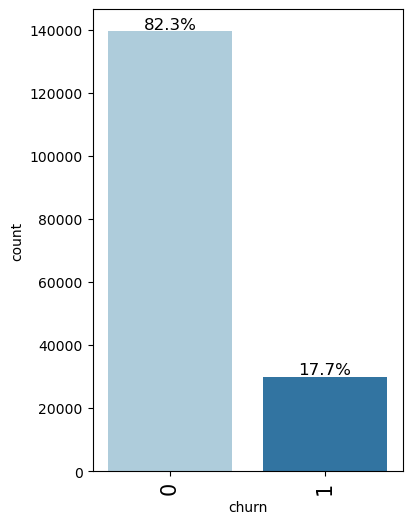

In [23]:
for i in cat_columns:
    labeled_barplot(df, i, perc=True,n=None)

`gender`
- There are more males compare to females, by about 3.8%

`marital_status`
- 55% of the clients are in category 3
- Category 1,2, and 5 are the minorities, totalling 14.4%

`job_position`
- 78.8% of clients are at job category 14.
- Category 1, 2, 4, 10, 15, shows significant amount of clients
- Category 5, 7, 9 has the least.

`education`
- 51.3% of clients are in category 4. Followed by category 2 at 42.5%.
- Category 1, 3, and 5 are rare.

`tariff_id`
- Majority of the clients are under tariff id of category 2 and 28.
- Significant number of clients under category 1, 3, 6, 18, 19, 20, 22, 23, 25.

`region`
- Client's region are not heavily clustered in one. Most popular region is in region 31.

`churn`
- We have imbalance issue, 17.7% clients churned.

### Multivariate

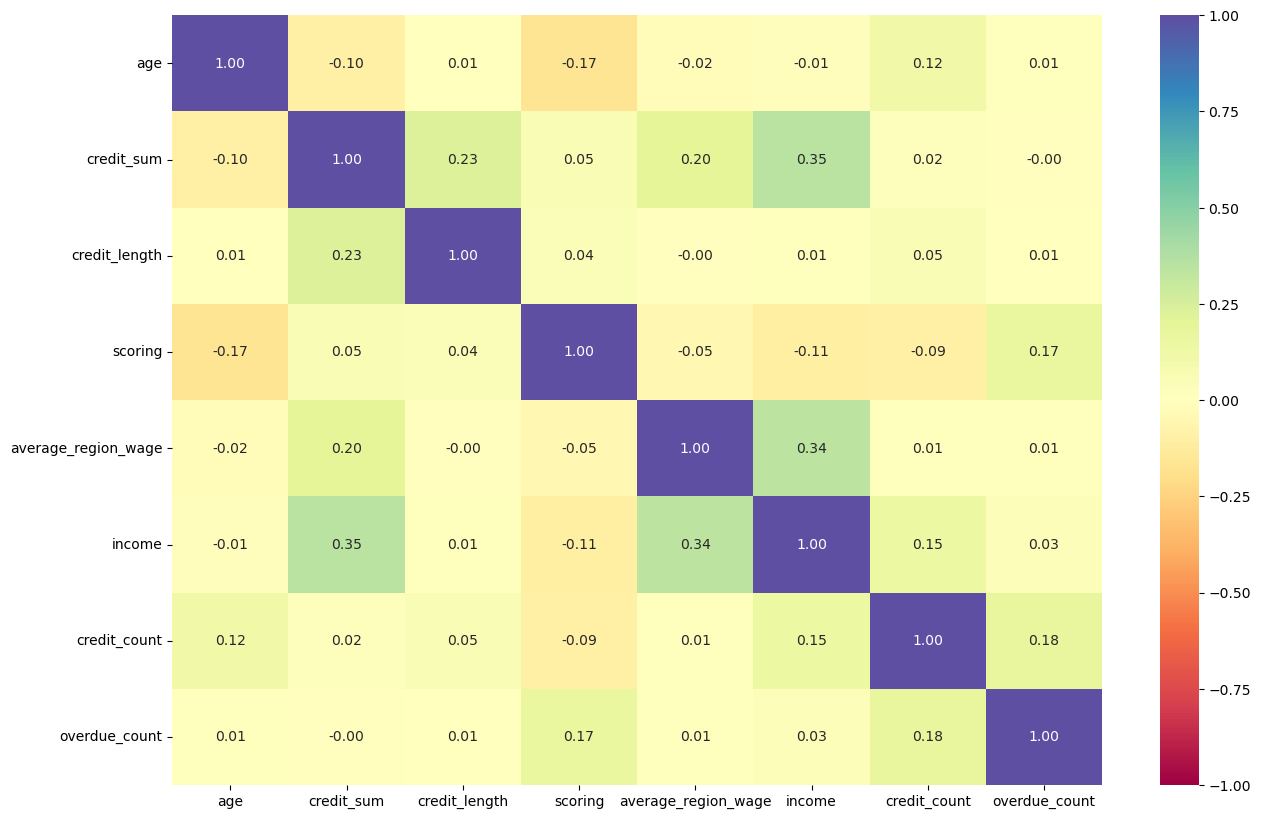

In [24]:
plt.figure(figsize=(15,10))
sns.heatmap(
    df[num_columns].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral'
)
plt.show()

- No special correlation in between the numerical features, mostly are self explanatory.

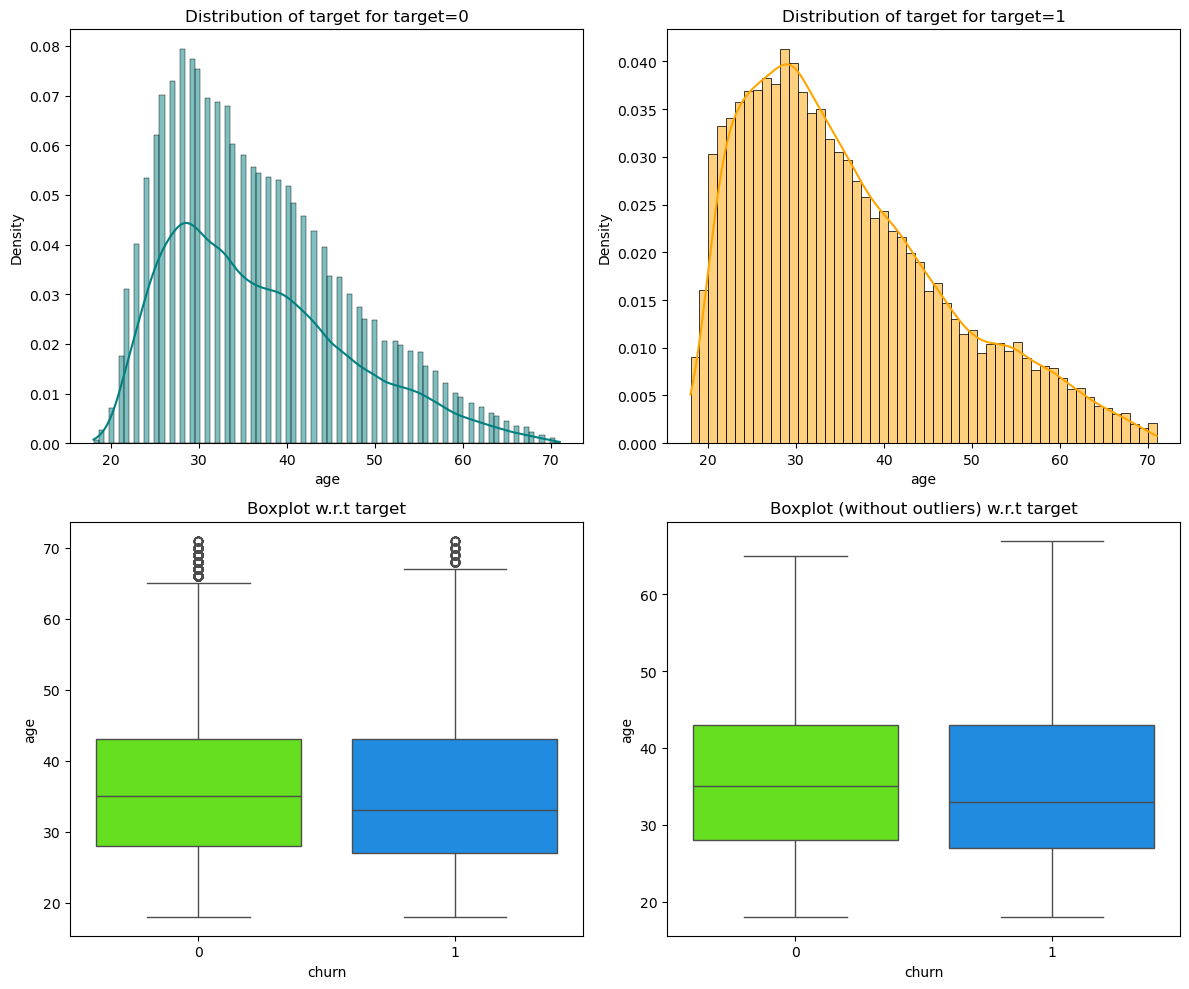

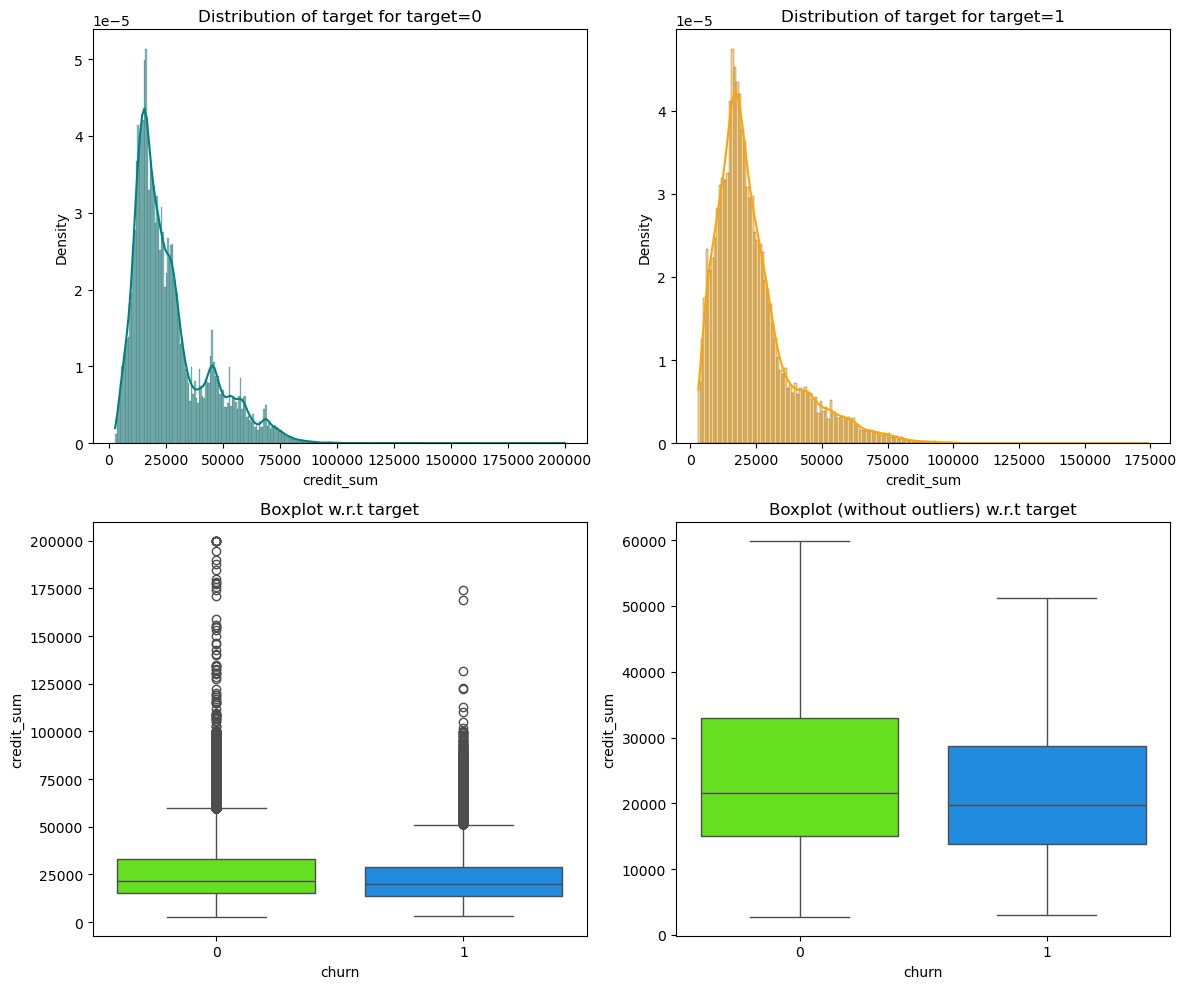

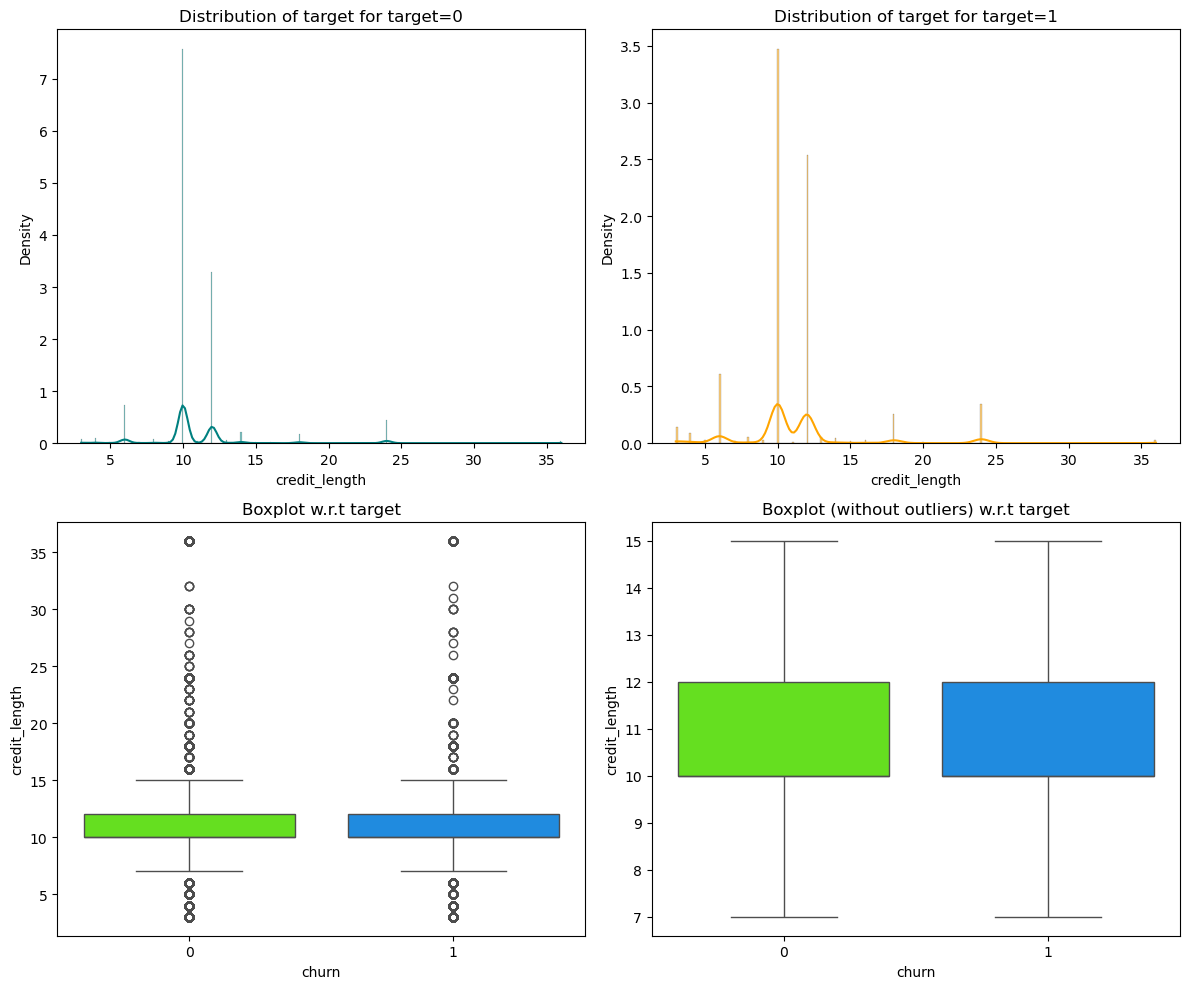

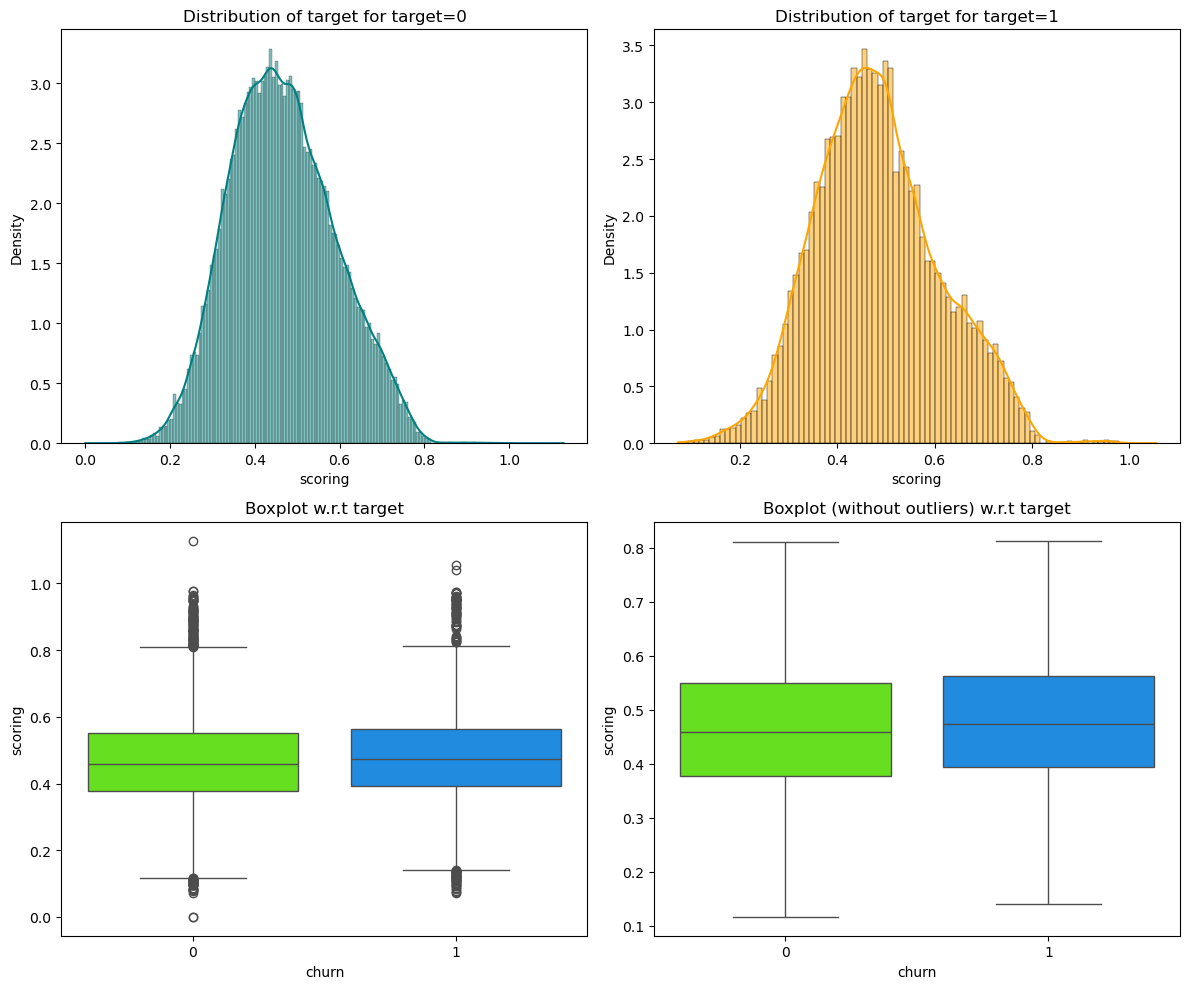

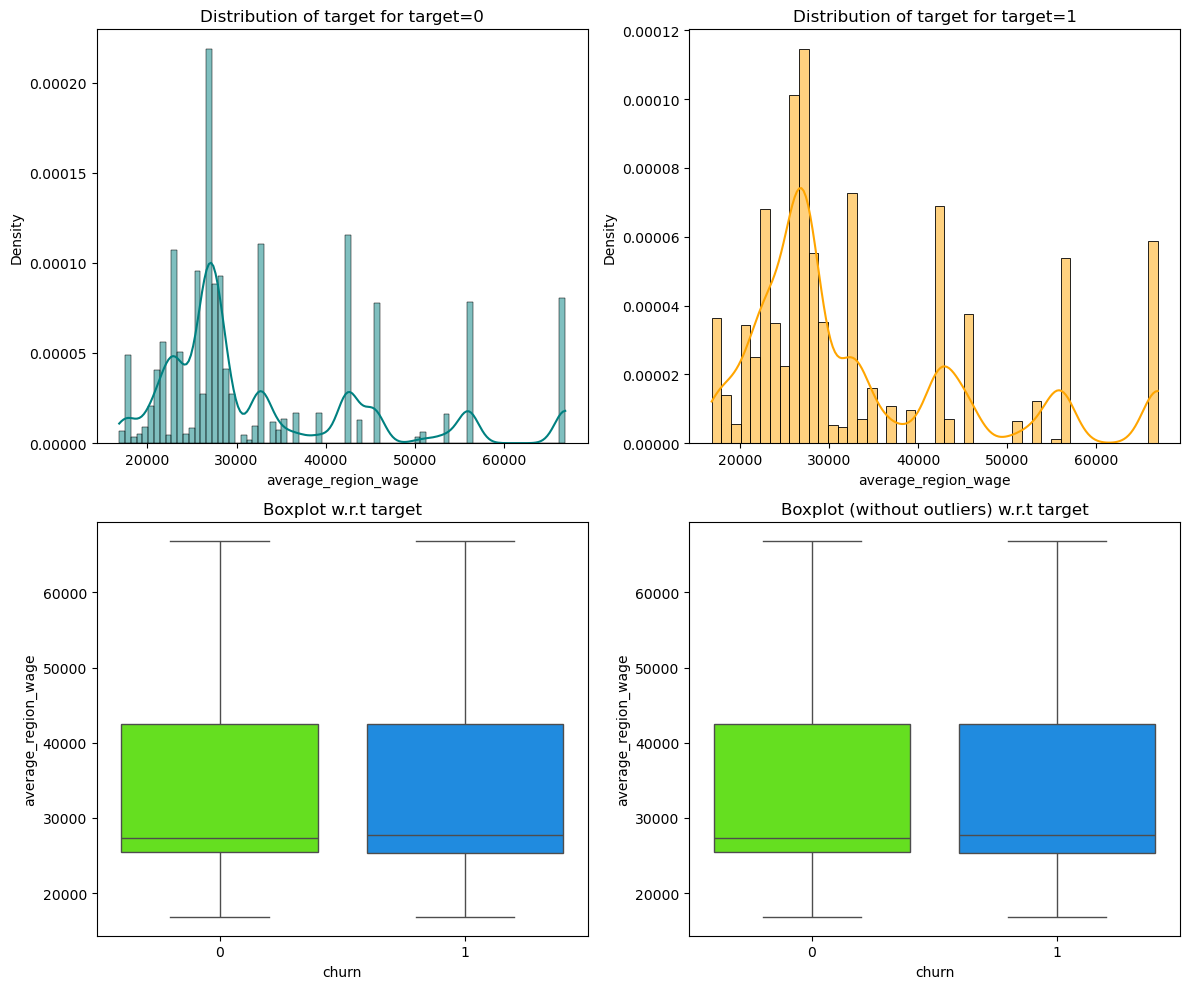

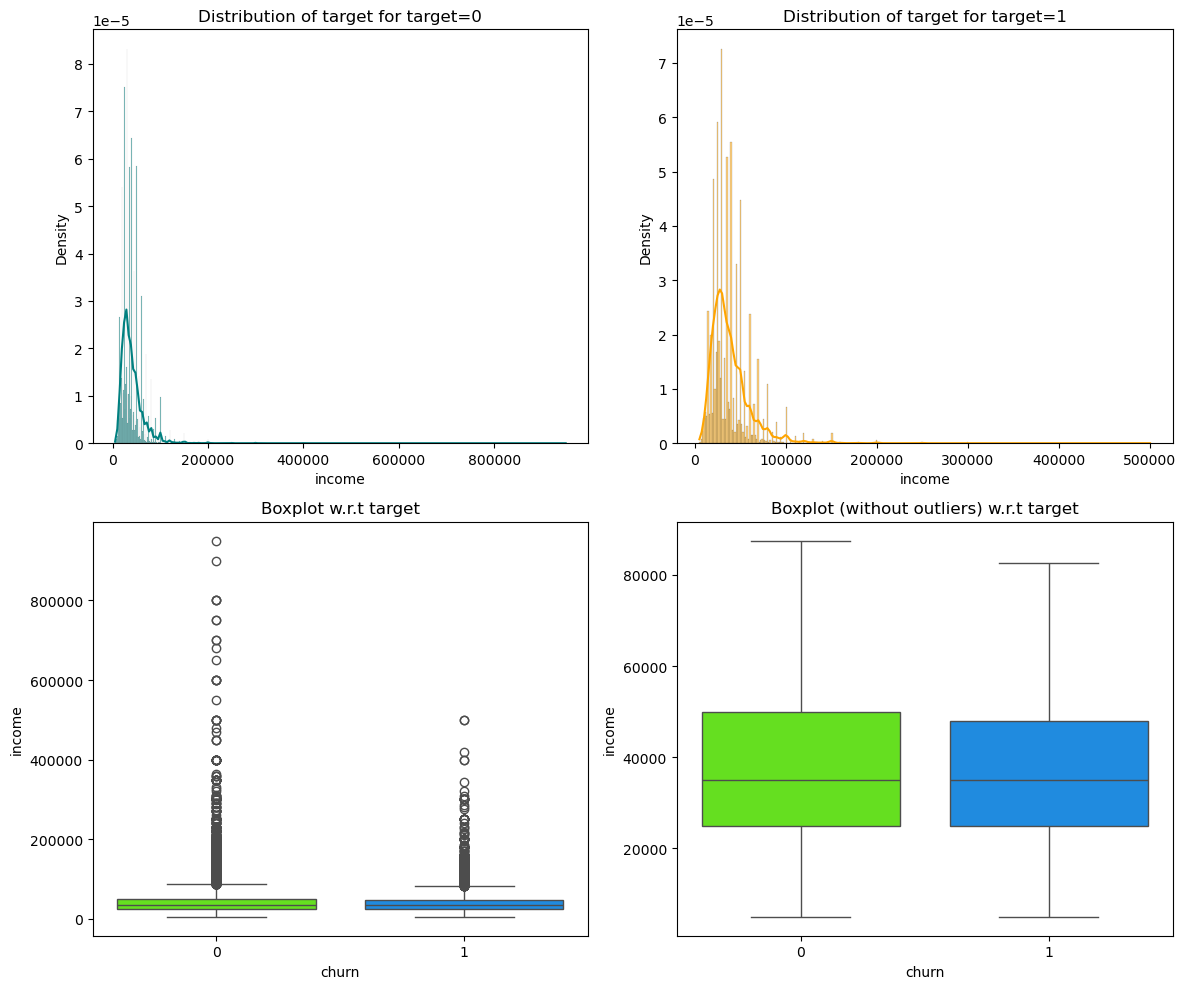

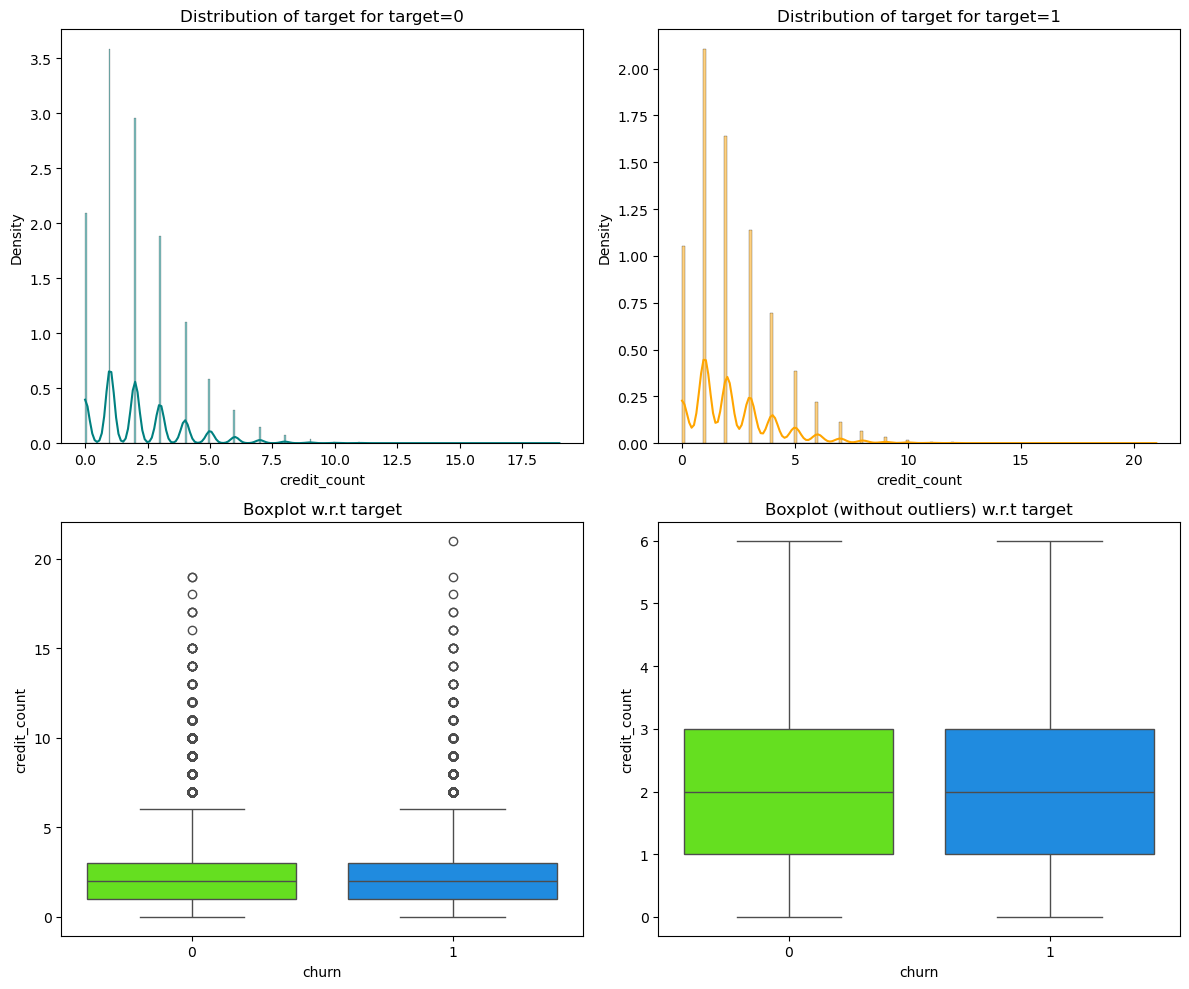

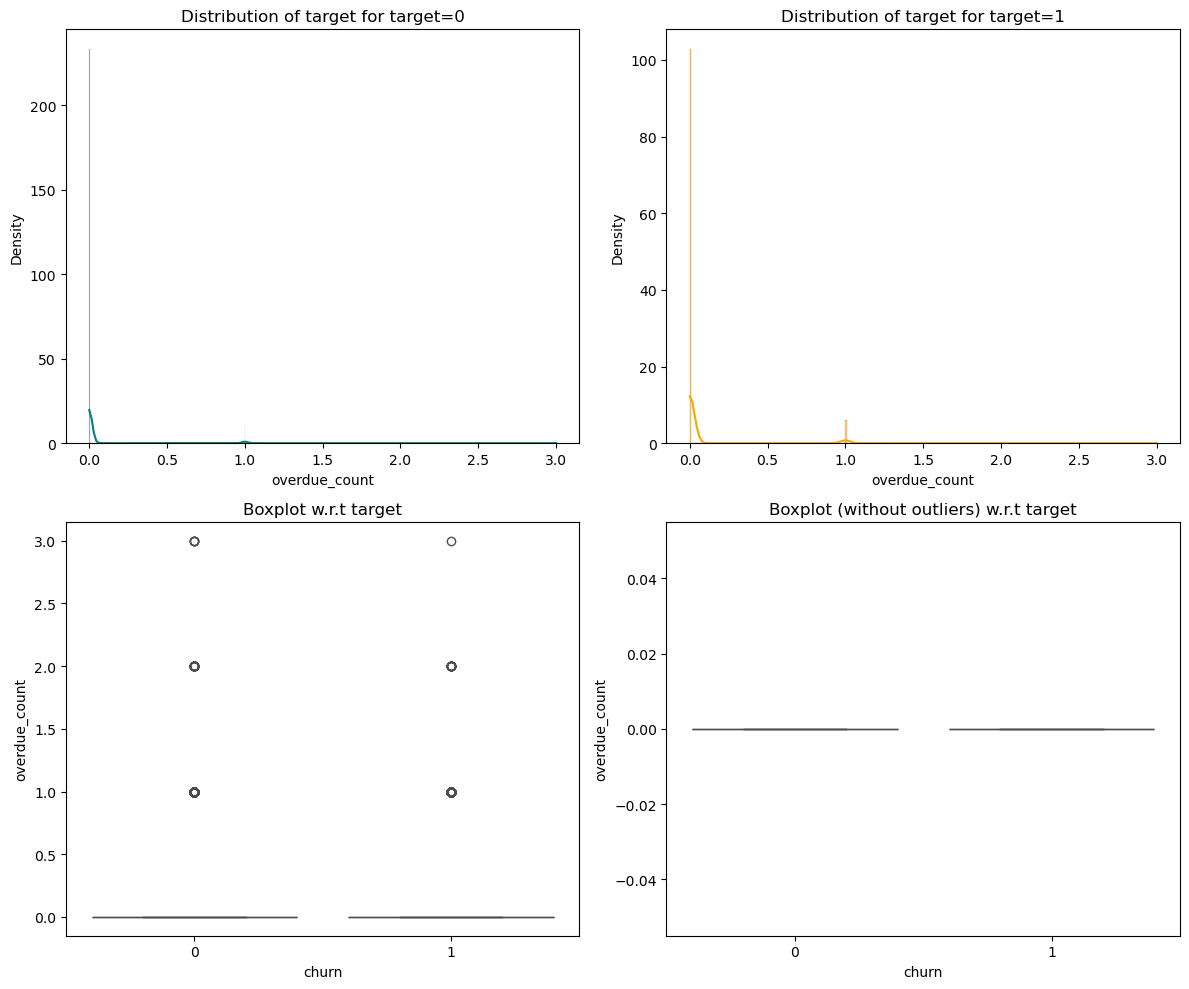

In [25]:
for i in num_columns:
    distribution_plot_wrt_target(df, i, 'churn')

`age`
- Plot shows more younger age clients churned

`credit_sum`
- Clients with lower credit sum churns more.

`credit_length`
- No obvious pattern observed.

`scoring`
- Looks like higher the score the more clients churned.

`average_region_wage`
- No obvious pattern.

`income`
- Lower income churns more.

`credit_count` and `overdue_count`
- Shows no obivous pattern.


churn        0      1     All
gender                       
All     139537  30056  169593
Female   65615  15881   81496
Male     73922  14175   88097
------------------------------------------------------------------------------------------------------------------------


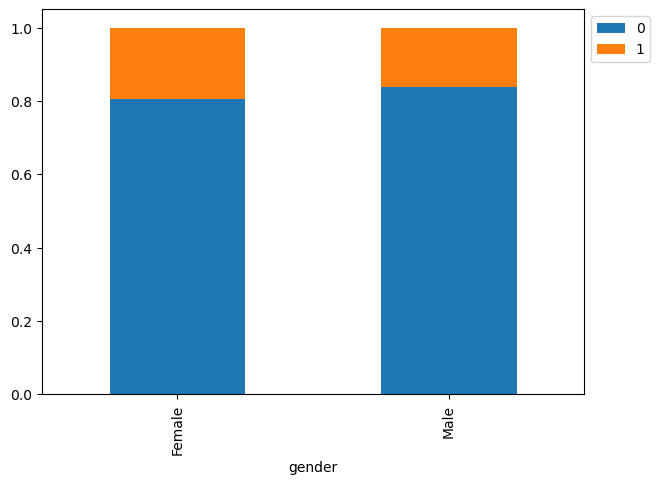

churn                0      1     All
marital_status                       
 All            139532  30056  169588
3.00             78938  14368   93306
4.00             40811  11016   51827
2.00             13746   3090   16836
1.00              3321    846    4167
5.00              2716    736    3452
------------------------------------------------------------------------------------------------------------------------


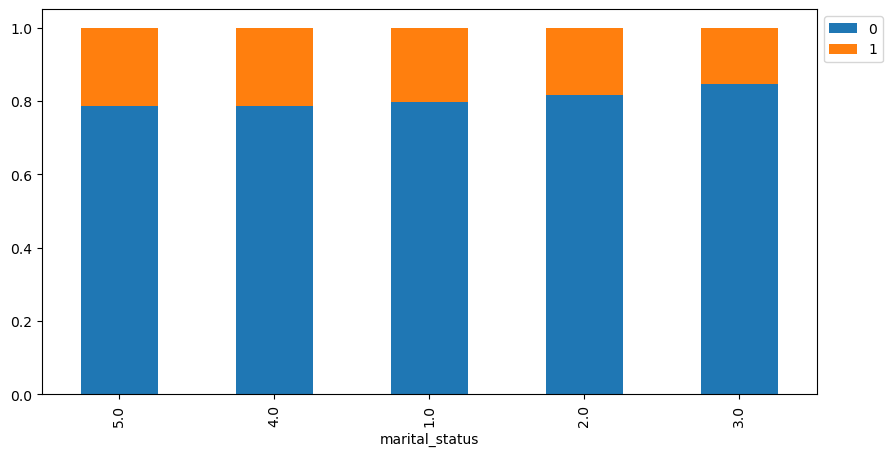

churn              0      1     All
job_position                       
All           139537  30056  169593
14            111308  22403  133711
15             14251   3340   17591
10              2601   1489    4090
2               4664    885    5549
1               1971    807    2778
4               3172    555    3727
8                343    194     537
17               532    121     653
16               267     84     351
6                173     67     240
3                 79     46     125
18                87     23     110
11                45     20      65
13                31      9      40
12                 6      6      12
7                  1      4       5
5                  6      2       8
9                  0      1       1
------------------------------------------------------------------------------------------------------------------------


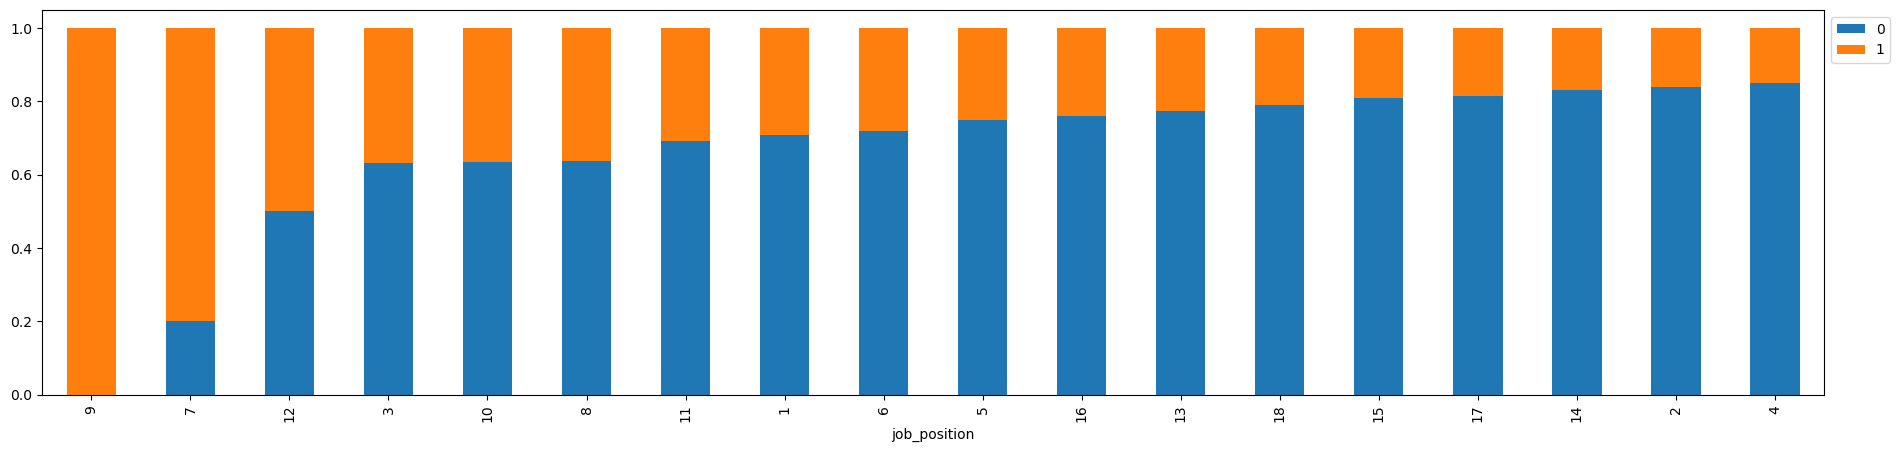

churn           0      1     All
education                       
 All       139535  30055  169590
4.00        69031  17955   86986
2.00        61916  10130   72046
5.00         8053   1837    9890
3.00          453    108     561
1.00           82     25     107
------------------------------------------------------------------------------------------------------------------------


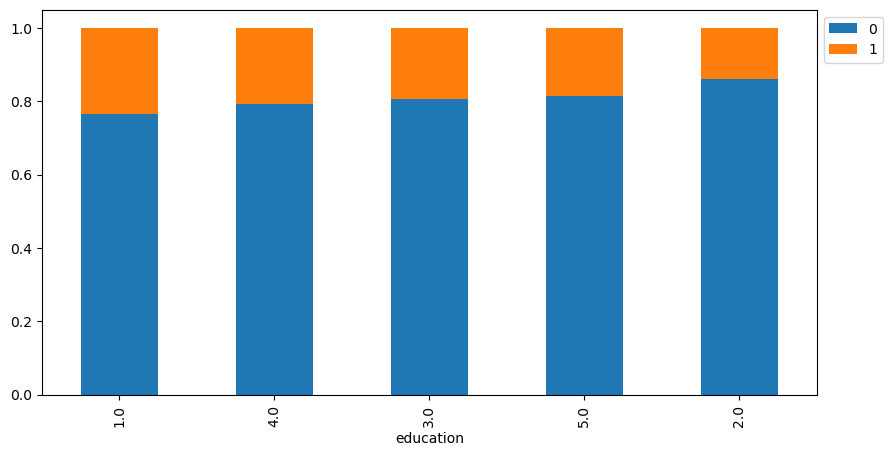

churn           0      1     All
tariff_id                       
All        139537  30056  169593
2           55702  13190   68892
19           9624   5866   15490
28          33249   5515   38764
20           9627   1253   10880
18           2347    992    3339
25           6726    726    7452
22           3422    474    3896
30           5157    369    5526
3            2844    349    3193
23           1935    285    2220
6            1851    235    2086
1            2080    159    2239
4             586    123     709
29            903    102    1005
31            236     78     314
7             473     66     539
8             697     61     758
12            256     47     303
32            368     46     414
5               3     33      36
21            106     26     132
9             558     17     575
11            350     15     365
10            355     14     369
13             41     13      54
17              0      1       1
14             10      1      11
27        

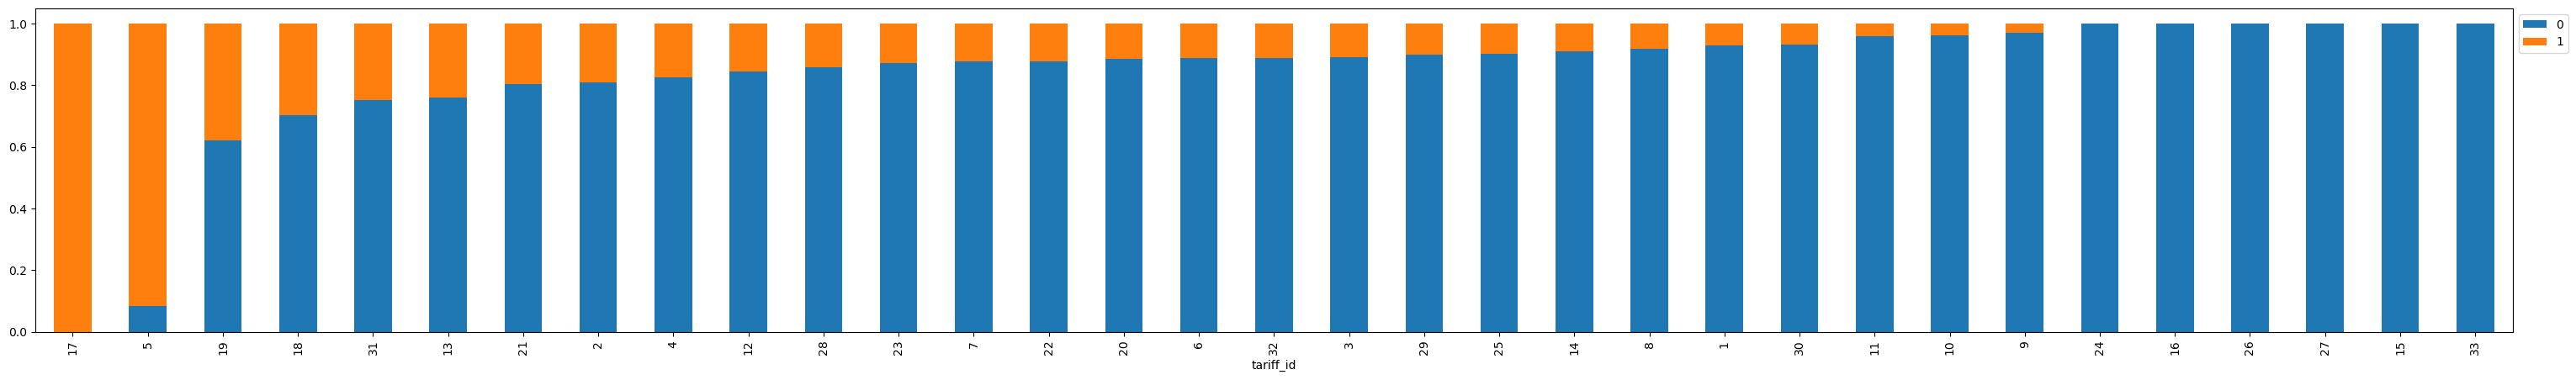

churn        0      1     All
region                       
 All    139348  30056  169404
31.00    10479   2258   12737
30.00     7281   1917    9198
73.00     6952   1736    8688
23.00     6622   1674    8296
63.00     7036   1228    8264
66.00     6084   1193    7277
57.00     6477   1130    7607
77.00     4166    954    5120
14.00     3355    935    4290
46.00     5499    934    6433
60.00     3440    856    4296
33.00     3011    651    3662
24.00     2474    630    3104
62.00     4462    612    5074
20.00     2275    592    2867
40.00     2996    590    3586
27.00     2922    587    3509
68.00     4113    455    4568
8.00      1867    413    2280
35.00     1741    412    2153
64.00     1866    404    2270
55.00     1448    400    1848
3.00      1530    354    1884
76.00     1203    347    1550
70.00     1214    323    1537
4.00      2383    319    2702
52.00     1535    319    1854
12.00      914    302    1216
47.00     1354    285    1639
10.00     1421    281    1702
7.00      

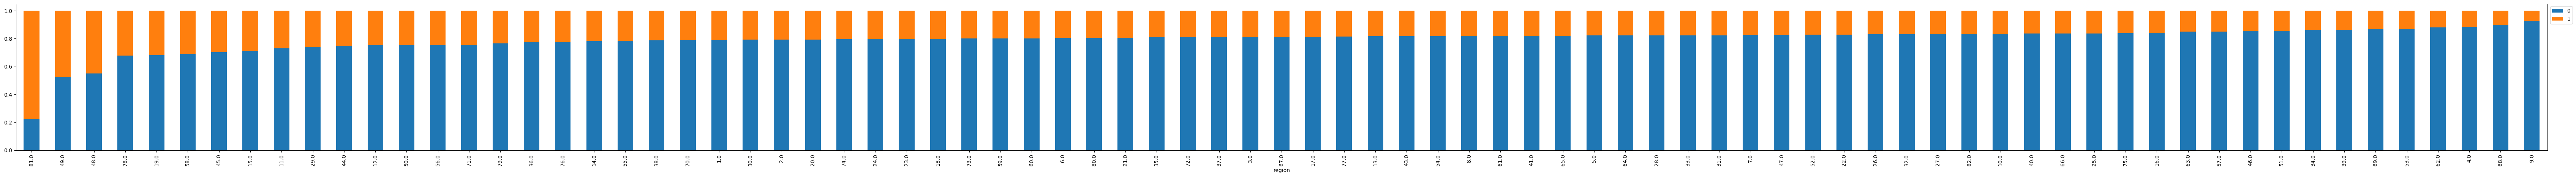

churn       0      1     All
churn                       
1           0  30056   30056
All    139537  30056  169593
0      139537      0  139537
------------------------------------------------------------------------------------------------------------------------


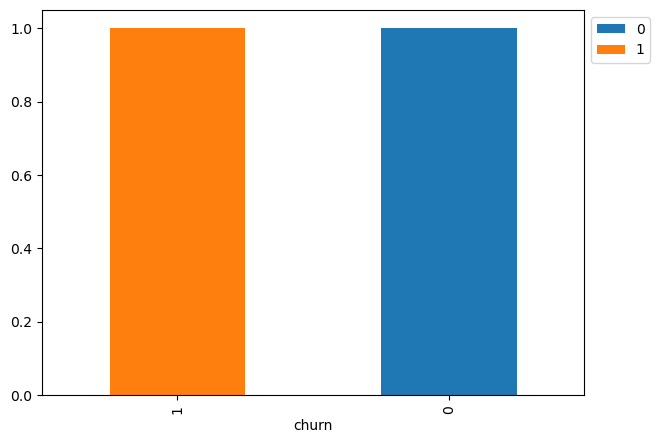

In [26]:
for i in cat_columns:
    stacked_barplot(df, i, 'churn')

`gender`
- Females churns more than male

`marital_status`
- Category 4 shows very high churn rate, comparable to category 5.
- Category 3, where majority is, shows the least churn rate.

`job_position`
- Category 4 shows the least churn rate. Followed by category 2.
- Category 14, where majority is at, has the 3rd least churn rate.
- Category 10 has very high churn rate.

`education`
- Category 2 has the least churn.
- Category 1 has highest churn rate.
- Category 4, where majority is, is the 2nd highest in churn rate.

`tariff_id`
- ID 1, 3, 8, 9, 10, 11, 25, 29, 30 has very low churn rate.
- ID 5 has very high churn rate.
- ID 18, 19 are significantly high in churning.

`region`
- Region 48, 49, 81 has significant churn rate.
- Region 4, 9 , 68 has the least churn rate.

## Modelling

### Data Preprocessing

#### Outlier treatment

In [27]:
df[df["age"] >68]

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn
51,Female,69,2.00,10,55900.00,18,0.39,2.00,20,31.00,42460.00,10000.00,0.00,0.00,0
114,Female,69,4.00,10,17558.00,10,0.42,4.00,2,9.00,28820.00,38800.00,3.00,0.00,0
1738,Male,70,3.00,14,55867.00,18,0.49,4.00,2,46.00,28160.00,25000.00,3.00,0.00,0
1808,Female,69,3.00,15,19268.00,10,0.46,4.00,2,70.00,20130.00,20000.00,1.00,0.00,0
2058,Female,70,3.00,15,68717.00,12,0.56,4.00,28,55.00,53460.00,43000.00,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168994,Male,69,5.00,10,77181.00,14,0.51,4.00,2,23.00,25850.00,27000.00,2.00,0.00,1
169863,Female,70,3.00,4,34189.00,12,0.46,2.00,2,40.00,27280.00,60000.00,0.00,0.00,0
170249,Male,69,3.00,14,11229.00,10,0.71,4.00,28,60.00,23320.00,23000.00,0.00,0.00,0
170263,Male,71,5.00,14,20408.00,36,0.55,2.00,2,55.00,53460.00,50000.00,0.00,0.00,0


<Axes: ylabel='credit_sum'>

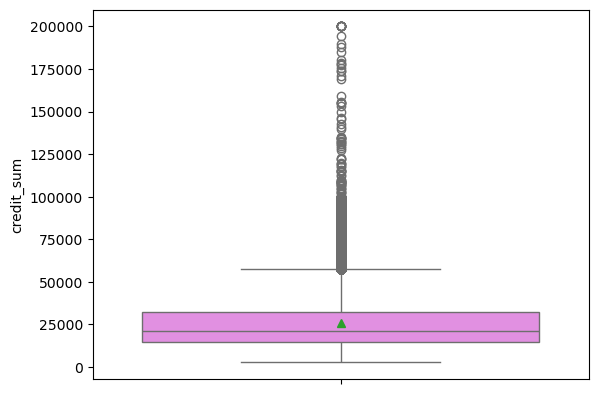

In [28]:
sns.boxplot(df['credit_sum'],showmeans=True, color="violet")

In [29]:
df[df['credit_sum']>175000]

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn
17910,Female,33,3.00,14,177480.00,24,0.39,2.00,20,60.00,23320.00,45000.00,2.00,0.00,0
27856,Female,44,3.00,4,200000.00,24,0.27,3.00,2,30.00,66880.00,230000.00,5.00,0.00,0
30931,Male,37,3.00,14,180000.00,24,0.29,2.00,2,41.00,33990.00,120000.00,3.00,0.00,0
32288,Female,33,2.00,14,200000.00,18,0.38,3.00,20,63.00,45430.00,100000.00,4.00,0.00,0
39340,Female,32,3.00,4,175670.06,12,0.23,2.00,28,31.00,42460.00,800000.00,9.00,0.00,0
44271,Female,23,4.00,3,200000.00,24,0.58,2.00,2,38.00,16830.00,30000.00,2.00,0.00,0
49274,Female,34,3.00,15,200000.00,12,0.33,2.00,20,40.00,27280.00,115000.00,3.00,0.00,0
49456,Female,24,4.00,14,189734.00,24,0.38,5.00,20,14.00,32450.00,28000.00,1.00,0.00,0
50370,Female,26,2.00,15,200000.00,12,0.56,2.00,25,12.00,25300.00,120000.00,1.00,0.00,0
50518,Female,40,3.00,15,200000.00,24,0.46,3.00,20,30.00,66880.00,300000.00,4.00,0.00,0


In [30]:
df[df['credit_length']>15]

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn
23,Male,22,4.00,14,30000.00,18,0.55,5.00,2,46.00,28160.00,30000.00,NaN,NaN,1
32,Female,44,4.00,14,26337.00,18,0.35,4.00,2,60.00,23320.00,18400.00,3.00,0.00,0
51,Female,69,2.00,10,55900.00,18,0.39,2.00,20,31.00,42460.00,10000.00,0.00,0.00,0
53,Male,29,2.00,14,33937.00,18,0.43,4.00,2,66.00,32780.00,40000.00,5.00,0.00,0
95,Female,30,3.00,14,29990.00,24,0.33,2.00,30,47.00,27720.00,30000.00,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170680,Female,33,3.00,14,12419.00,24,0.49,2.00,2,82.00,26620.00,24000.00,1.00,0.00,0
170690,Male,49,3.00,14,22380.00,24,0.37,4.00,30,62.00,27060.00,22000.00,3.00,0.00,0
170703,Male,38,3.00,8,63677.00,24,0.45,4.00,2,23.00,25850.00,25000.00,3.00,0.00,0
170727,Female,25,4.00,2,67989.00,18,0.47,2.00,2,24.00,29260.00,50000.00,NaN,NaN,1


- These are all actual values, no treatment will be done.

- No columns will be dropped as all contains valuable information.

#### Synthesize unique ID

In [31]:
df = df.reset_index(drop=True)
df['unique_id'] = df.index

In [32]:
df.head()

,gender,age,marital_status,job_position,credit_sum,credit_length,scoring,education,tariff_id,region,average_region_wage,income,credit_count,overdue_count,churn,unique_id
0,Female,48,3.00,15,59998.00,10,0.77,2.00,28,23.00,25850.00,30000.00,1.00,1.00,0,0
1,Male,28,NaN,15,10889.00,6,0.25,2.00,2,30.00,66880.00,43000.00,2.00,0.00,0,1
2,Female,32,3.00,14,10728.00,12,0.46,4.00,2,64.00,23430.00,23000.00,5.00,0.00,0,2
3,Male,27,2.00,14,12009.09,12,0.36,2.00,2,8.00,23650.00,17000.00,2.00,0.00,0,3
4,Female,45,3.00,14,16908.89,10,0.42,4.00,2,77.00,26620.00,NaN,1.00,0.00,0,4


### Data Preparation for Modelling

#### Splitting data

In [33]:
X = df.drop(['churn','unique_id'],axis=1)
X = pd.get_dummies(X)

Y = df['churn'].apply(lambda x: 1 if x == 1 else 0)

In [34]:
X.shape

(169593, 152)

In [35]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=1, stratify=Y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(101755, 152) (33919, 152) (33919, 152)


In [36]:
id_train = df.loc[X_train.index, "unique_id"]
id_val = df.loc[X_val.index, "unique_id"]
id_test  = df.loc[X_test.index, "unique_id"]

id_train = id_train.reset_index(drop=True)
id_val = id_val.reset_index(drop=True)
id_test = id_test.reset_index(drop=True)

In [37]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (101755, 152)
Shape of test set :  (33919, 152)
Percentage of classes in training set:
churn
0   0.82
1   0.18
Name: proportion, dtype: float64
Percentage of classes in test set:
churn
0   0.82
1   0.18
Name: proportion, dtype: float64


#### Missing value treatment

- We impute all the columns that has missing data with median value. 

In [38]:
imputer = SimpleImputer(strategy="median")

In [39]:
# Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)

In [40]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

age                    0
credit_sum             0
credit_length          0
scoring                0
average_region_wage    0
income                 0
credit_count           0
overdue_count          0
gender_Female          0
gender_Male            0
marital_status_1.0     0
marital_status_2.0     0
marital_status_3.0     0
marital_status_4.0     0
marital_status_5.0     0
job_position_1         0
job_position_2         0
job_position_3         0
job_position_4         0
job_position_5         0
job_position_6         0
job_position_7         0
job_position_8         0
job_position_9         0
job_position_10        0
job_position_11        0
job_position_12        0
job_position_13        0
job_position_14        0
job_position_15        0
job_position_16        0
job_position_17        0
job_position_18        0
education_1.0          0
education_2.0          0
education_3.0          0
education_4.0          0
education_5.0          0
tariff_id_1            0
tariff_id_2            0


In [41]:
print(X_train.shape, X_val.shape, X_test.shape)

(101755, 152) (33919, 152) (33919, 152)


### Model building

#### Model evaluation criterion:

**Model can make wrong predictions as:**
- Predicting a client churned but client didn't churn (FP).
- Predicting a client doesn't churn but client churned (FN).

**Which case is more important?**
- Predicting TP increases income and prolonged clients lifetime.
- Predicting FP will cost the bank incur incentive to clients who wouldn't churn.
- Predicting FN will lose potential clients lifetime value.

**How to reduce the losses?**

We want to minimize both FP and FN since both matters. We predict the churn probability and then to optimize expected profit:

$$ \textrm{Expected Profit} = ( \textrm{TP} \times \textrm{Client Value} ) - ( \textrm{FP} \times \textrm{Retention Cost} )  $$

#### Logit model

##### **Fit with balancing class weight**

In [42]:
lr = LogisticRegression(random_state=1,class_weight='balanced')
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

##### **Check multicollinearity**

In [43]:
%%time
checking_vif(X_train)

CPU times: total: 13min 58s
Wall time: 2min 36s


,feature,VIF
0,age,1.38
1,credit_sum,1.36
2,credit_length,1.21
3,scoring,1.84
4,average_region_wage,inf
5,income,1.53
6,credit_count,1.10
7,overdue_count,1.08
8,gender_Female,inf
9,gender_Male,inf


In [44]:
# X_train1 = X_train.drop(
#     ["average_region_wage",
#      'marital_status_2.0',
#      "job_position_1",
#      "job_position_4",
#      'education_2.0',
#      "tariff_id_1",
#      "tariff_id_18",
#      "tariff_id_22",
#      "tariff_id_23",
#      "tariff_id_30",
#           "tariff_id_7",
#           "tariff_id_8",
#           "tariff_id_12",
#           "tariff_id_32",
#      'region_3.0',
#      'region_4.0',
#      'region_31.0',
#           # 'region_31.0',
#      ],
#     axis=1
# )

# checking_vif(X_train1)

In [45]:
def remove_high_corr(X, threshold=0.9):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=drop)

In [46]:
def remove_multicollinearity_vif(X, threshold=5.0):
    X = X.copy()
    
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        )
        
        max_vif = vif.max()
        
        if max_vif <= threshold:
            break
            
        drop_feature = vif.idxmax()
        print(f"Dropping {drop_feature} (VIF = {max_vif:.2f})")
        X = X.drop(columns=[drop_feature])
    
    return X

In [47]:
X_train2 = remove_high_corr(X_train, 0.9)

In [48]:
%%time
X_train2 = remove_multicollinearity_vif(X_train2, threshold=5)

Dropping average_region_wage (VIF = inf)
Dropping job_position_1 (VIF = inf)
Dropping tariff_id_2 (VIF = 34935.26)
Dropping marital_status_3.0 (VIF = 11312.20)
Dropping education_4.0 (VIF = 505.78)
Dropping job_position_14 (VIF = 46.92)
Dropping scoring (VIF = 27.33)
Dropping age (VIF = 17.26)
Dropping credit_length (VIF = 12.27)
Dropping income (VIF = 5.42)
CPU times: total: 2h 17min 24s
Wall time: 26min 11s


In [49]:
X_train2.head()

,credit_sum,credit_count,overdue_count,gender_Female,marital_status_1.0,marital_status_2.0,marital_status_4.0,marital_status_5.0,job_position_2,job_position_3,job_position_4,job_position_5,job_position_6,job_position_7,job_position_8,job_position_9,job_position_10,job_position_11,job_position_12,job_position_13,job_position_15,job_position_16,job_position_17,job_position_18,education_1.0,education_2.0,education_3.0,education_5.0,tariff_id_1,tariff_id_3,tariff_id_4,tariff_id_5,tariff_id_6,tariff_id_7,tariff_id_8,tariff_id_9,tariff_id_10,tariff_id_11,tariff_id_12,tariff_id_13,tariff_id_14,tariff_id_15,tariff_id_16,tariff_id_17,tariff_id_18,tariff_id_19,tariff_id_20,tariff_id_21,tariff_id_22,tariff_id_23,tariff_id_24,tariff_id_25,tariff_id_26,tariff_id_27,tariff_id_28,tariff_id_29,tariff_id_30,tariff_id_31,tariff_id_32,tariff_id_33,region_1.0,region_2.0,region_3.0,region_4.0,region_5.0,region_6.0,region_7.0,region_8.0,region_9.0,region_10.0,region_11.0,region_12.0,region_13.0,region_14.0,region_15.0,region_16.0,region_17.0,region_18.0,region_19.0,region_20.0,region_21.0,region_22.0,region_23.0,region_24.0,region_25.0,region_26.0,region_27.0,region_28.0,region_29.0,region_30.0,region_31.0,region_32.0,region_33.0,region_34.0,region_35.0,region_36.0,region_37.0,region_38.0,region_39.0,region_40.0,region_41.0,region_43.0,region_44.0,region_45.0,region_46.0,region_47.0,region_48.0,region_49.0,region_50.0,region_51.0,region_52.0,region_53.0,region_54.0,region_55.0,region_56.0,region_57.0,region_58.0,region_59.0,region_60.0,region_61.0,region_62.0,region_63.0,region_64.0,region_65.0,region_66.0,region_67.0,region_68.0,region_69.0,region_70.0,region_71.0,region_72.0,region_73.0,region_74.0,region_75.0,region_76.0,region_77.0,region_78.0,region_79.0,region_80.0,region_81.0,region_82.0
0,53189.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,12258.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,37324.80,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,9989.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0

##### **Removing high p-values**

In [50]:
# initial list of columns
cols = X_train2.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train2[cols]

    # fitting the model
    model = sm.Logit(list(y_train), X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['credit_sum', 'credit_count', 'overdue_count', 'gender_Female', 'marital_status_1.0', 'marital_status_2.0', 'marital_status_4.0', 'marital_status_5.0', 'job_position_3', 'job_position_6', 'job_position_8', 'job_position_10', 'job_position_12', 'job_position_15', 'education_2.0', 'tariff_id_1', 'tariff_id_3', 'tariff_id_4', 'tariff_id_5', 'tariff_id_6', 'tariff_id_8', 'tariff_id_9', 'tariff_id_10', 'tariff_id_11', 'tariff_id_18', 'tariff_id_19', 'tariff_id_20', 'tariff_id_22', 'tariff_id_23', 'tariff_id_25', 'tariff_id_28', 'tariff_id_29', 'tariff_id_30', 'tariff_id_31', 'tariff_id_32', 'region_1.0', 'region_2.0', 'region_3.0', 'region_4.0', 'region_5.0', 'region_6.0', 'region_7.0', 'region_8.0', 'region_9.0', 'region_10.0', 'region_11.0', 'region_12.0', 'region_13.0', 'region_14.0', 'region_15.0', 'region_16.0', 'region_17.0', 'region_18.0', 'region_19.0', 'region_20.0', 'region_21.0', 'region_22.0', 'region_23.0', 'region_24.0', 'region_25.0', 'region_26.0', 'region_27.0', 'region_28

##### **Fit with newly selected features**

In [51]:
X_train3 = X_train2[selected_features]

In [52]:
lr.fit(X_train3, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

##### **Check training and validation performance with default threshold**

Training performance:
    Accuracy  Recall  Precision   F1
0      0.64    0.60       0.27 0.37


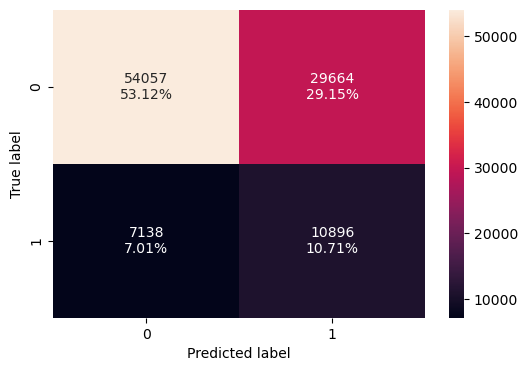

In [53]:
# Calculating different metrics on train set
log_reg_model_train_perf = model_performance_classification_sklearn(
    lr, X_train3, y_train
)
print("Training performance:\n", log_reg_model_train_perf)


# creating confusion matrix
confusion_matrix_sklearn(lr, X_train3, y_train)

In [54]:
X_val1 = X_val[list(X_train3.columns)]

Validation performance:
    Accuracy  Recall  Precision   F1
0      0.64    0.61       0.27 0.38


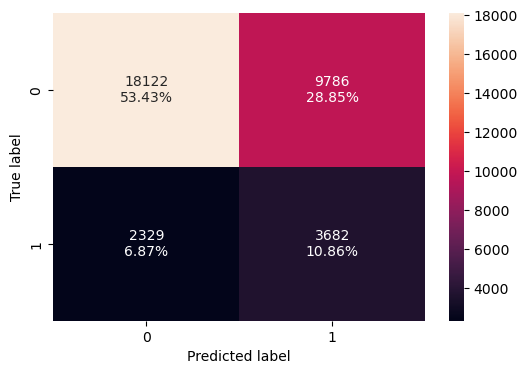

In [55]:
# Calculating different metrics on validation set
log_reg_model_val_perf = model_performance_classification_sklearn(lr, X_val1, y_val)
print("Validation performance:\n",log_reg_model_val_perf)

# creating confusion matrix
confusion_matrix_sklearn(lr, X_val1, y_val)

##### **We find the optimal threshold via ROC-AUC and PR-curve**

In [56]:
# predict probabilities using selected features
y_prob_lg = lr.predict_proba(X_train3)[:, 1]

###### **ROC-AUC**

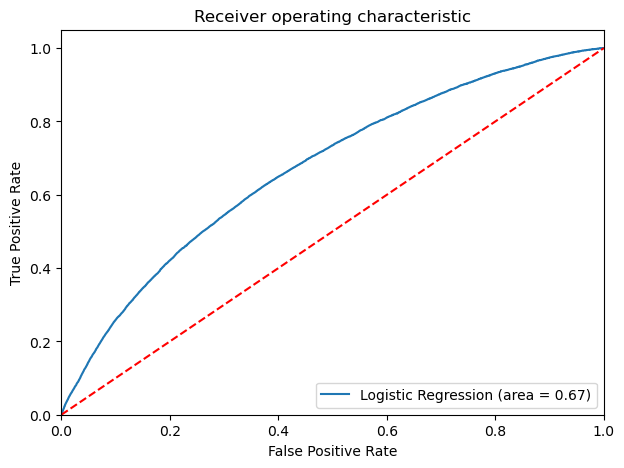

In [57]:
logit_roc_auc_train = roc_auc_score(y_train,y_prob_lg)
fpr, tpr, thresholds = roc_curve(y_train, y_prob_lg)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [58]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, y_prob_lg)

optimal_idx = np.argmax(tpr - fpr)
lg_optimal_threshold_auc_roc = thresholds[optimal_idx]
print(lg_optimal_threshold_auc_roc)

0.4935442930555776


###### **PR-curve**

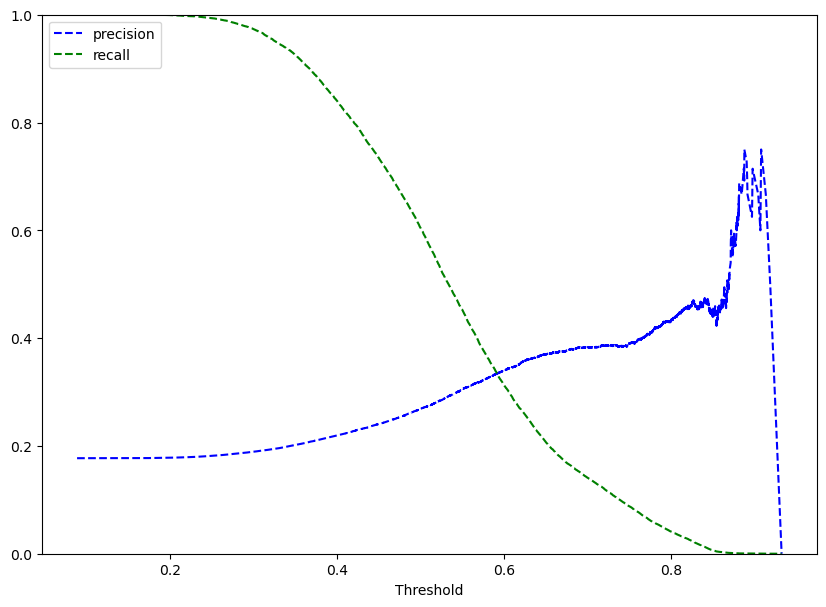

In [59]:
prec, rec, tre = precision_recall_curve(y_train, y_prob_lg)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [60]:
# searching the intersection point of recall and precision
print(intersection(rec.tolist(),prec.tolist()))
intersected = intersection(rec.tolist(),prec.tolist())

[1.0, 1.0, 1.0, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.49295774647887325, 0.49295774647887325, 0.49295774647887325, 0.468503937007874, 0.468503937007874, 0.4647887323943662, 0.4645669291338583, 0.45774647887323944, 0.4566929133858268, 0.4566929133858268, 0.4566929133858268, 0.4566929133858268, 0.4507042253521127, 0.4507042253521127, 0.4507042253521127, 0.4507042253521127, 0.4409448818897638, 0.4409448818897638, 0.4409448818897638, 0.421259842519685, 0.421259842519685, 0.421259842519685, 0.421259842519685, 0.421259842519685, 0.421259842519685, 0.4094488188976378, 0.38976377952755903, 0.38976377952755903, 0.3858267716535433, 0.37362759232560716, 0.37362759232560716, 0.3543307086614173, 0.3543307086614173, 0.3543307086614173, 0.3543307086614173, 0.3543307086614173, 0.3543307086614173, 0.3543307086614173, 0.33442386603083063, 0.33442386603083063, 0.33442386603083063, 0.33442386603083063, 0.3228346456692913, 0.3228346456692913, 0.3228346456692913, 0.3228346456692913, 0.3228346456692913, 0.32283464

In [61]:
# extract the threshold 
intersect = pd.DataFrame({'prec': prec[:-1],
                          'rec': rec[:-1],
                          'tre': tre})

intersect[intersect['prec'] == 0.33442386603083063]

,prec,rec,tre
83304,0.33,0.33,0.59


In [62]:
# setting the threshold
lg_optimal_threshold_curve = 0.59

##### **Check training and validation performance with new threshold**

**Training set**

Training performance:
    Accuracy  Recall  Precision   F1
0      0.63    0.62       0.26 0.37


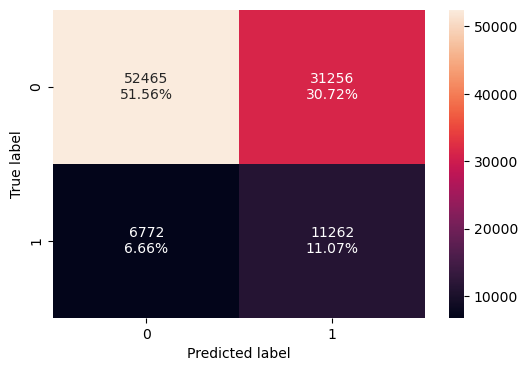

In [63]:
# checking model performance for AUC-ROC threshold
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_sklearn(
    lr, X_train3, y_train, lg_optimal_threshold_auc_roc
)
print("Training performance:\n",log_reg_model_train_perf_threshold_auc_roc)

# create confusion matrix
confusion_matrix_sklearn(lr, X_train3, y_train, lg_optimal_threshold_auc_roc)

Training performance:
    Accuracy  Recall  Precision   F1
0      0.76    0.34       0.33 0.34


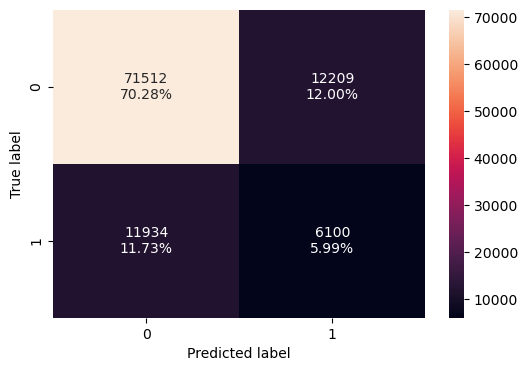

In [64]:
# checking model performance for PR-curve threshold
log_reg_model_train_perf_threshold_curve = model_performance_classification_sklearn(
    lr, X_train3, y_train, lg_optimal_threshold_curve
)
print("Training performance:\n",log_reg_model_train_perf_threshold_curve)

# create confusion matrix
confusion_matrix_sklearn(lr, X_train3, y_train, lg_optimal_threshold_curve)

**Validation set**

Training performance:
    Accuracy  Recall  Precision   F1
0      0.63    0.63       0.27 0.38


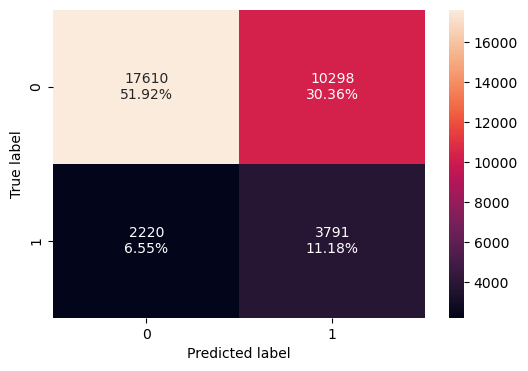

In [65]:
# checking model performance for AUC-ROC threshold
log_reg_model_val_perf_threshold_auc_roc = model_performance_classification_sklearn(
    lr, X_val1, y_val, lg_optimal_threshold_auc_roc
)
print("Training performance:\n",log_reg_model_val_perf_threshold_auc_roc)

# create confusion matrix
confusion_matrix_sklearn(lr, X_val1, y_val, lg_optimal_threshold_auc_roc)

Training performance:
    Accuracy  Recall  Precision   F1
0      0.77    0.35       0.34 0.35


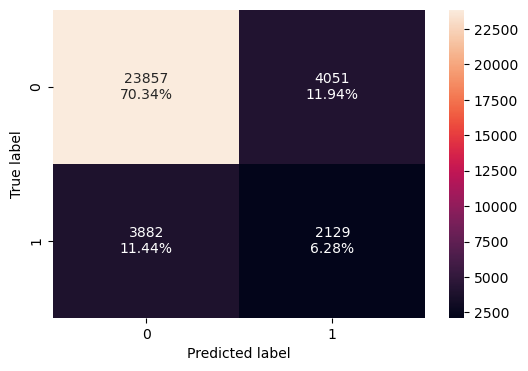

In [66]:
# checking model performance for PR-curver threshold
log_reg_model_val_perf_threshold_curve = model_performance_classification_sklearn(
    lr, X_val1, y_val, lg_optimal_threshold_curve
)
print("Training performance:\n",log_reg_model_val_perf_threshold_curve)

# create confusion matrix
confusion_matrix_sklearn(lr, X_val1, y_val, lg_optimal_threshold_curve)

##### **Compare result**

In [67]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.49 Threshold",
    "Logistic Regression-0.59 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.49 Threshold,Logistic Regression-0.59 Threshold
Accuracy,0.64,0.63,0.76
Recall,0.60,0.62,0.34
Precision,0.27,0.26,0.33
F1,0.37,0.37,0.34


In [68]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        log_reg_model_val_perf_threshold_auc_roc.T,
        log_reg_model_val_perf_threshold_curve.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.49 Threshold",
    "Logistic Regression-0.59 Threshold",
]

print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.49 Threshold,Logistic Regression-0.59 Threshold
Accuracy,0.64,0.63,0.77
Recall,0.61,0.63,0.35
Precision,0.27,0.27,0.34
F1,0.38,0.38,0.35


Observation:
- The default model performed better. This means the model is underfitting. This is due to nonlinearity of the datasets.
- We proceed with XGBoost.

#### XGboost model

##### **Fitting on train and validation set**

In [69]:
#Fitting the model
xgb_classifier = XGBClassifier(random_state=1, eval_metric='auc')
xgb_classifier.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Training performance:
    Accuracy  Recall  Precision   F1
0      0.85    0.20       0.75 0.32


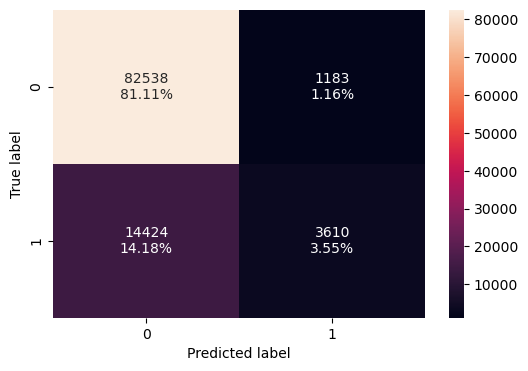

In [70]:
#Calculating different metrics
xgb_classifier_model_train_perf=model_performance_classification_sklearn(xgb_classifier,X_train,y_train)
print("Training performance:\n",xgb_classifier_model_train_perf)
#Creating confusion matrix
confusion_matrix_sklearn(xgb_classifier,X_train,y_train)

Validation performance:
    Accuracy  Recall  Precision   F1
0      0.83    0.14       0.54 0.22


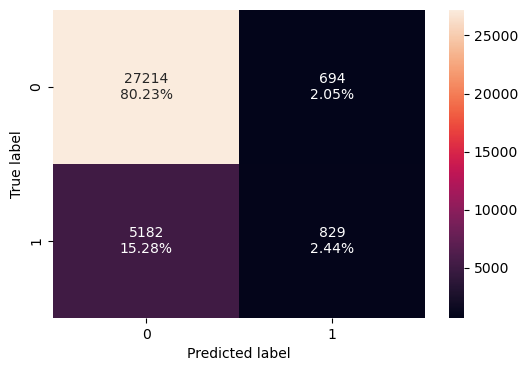

In [71]:
xgb_classifier_model_val_perf=model_performance_classification_sklearn(xgb_classifier,X_val,y_val)
print("Validation performance:\n",xgb_classifier_model_val_perf)
#Creating confusion matrix
confusion_matrix_sklearn(xgb_classifier,X_val,y_val)

- No signs of overfitting but underfitting instead, we proceed with tuning

##### **Hyperparameter tuning**

###### **Tier 1 tuning**

In [72]:
%%time
# Choose the type of classifier. 
xgb_tuned_T1 = XGBClassifier(random_state=1, eval_metric='auc')

# Grid of parameters to choose from
parameters = {
    "scale_pos_weight":[3, 4, 4.5, 5, 6],
    'max_depth': [3, 4, 5, 6],
    "learning_rate":[0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 500],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned_T1, parameters,scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned_T1 = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned_T1.fit(X_train, y_train)

CPU times: total: 9h 26min 31s
Wall time: 56min 37s


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Training performance:
    Accuracy  Recall  Precision   F1
0      0.57    0.81       0.27 0.40


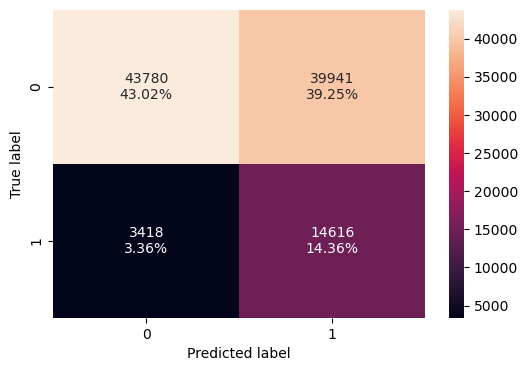

In [73]:
#Calculating different metrics
xgb_tuned_T1_model_train_perf=model_performance_classification_sklearn(xgb_tuned_T1,X_train,y_train)
print("Training performance:\n",xgb_tuned_T1_model_train_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T1,X_train,y_train)

Validation performance:
    Accuracy  Recall  Precision   F1
0      0.57    0.80       0.26 0.40


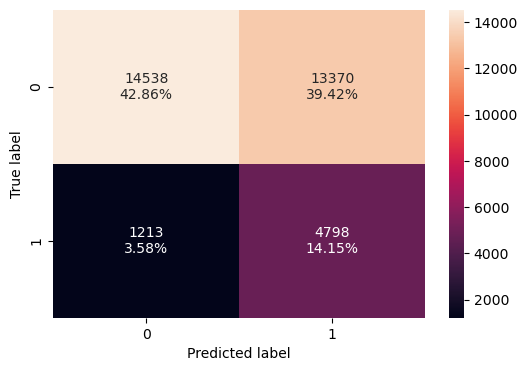

In [74]:
#Calculating different metrics
xgb_tuned_T1_model_val_perf=model_performance_classification_sklearn(xgb_tuned_T1,X_val,y_val)
print("Validation performance:\n",xgb_tuned_T1_model_val_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T1,X_val,y_val)

###### **Tier 2 tuning**

In [75]:
%%time
# Grid of parameters to choose from
parameters = {
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned_T1, parameters,scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned_T2 = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned_T2.fit(X_train, y_train)

CPU times: total: 1h 41min 8s
Wall time: 10min 4s


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Training performance:
    Accuracy  Recall  Precision   F1
0      0.56    0.82       0.26 0.40


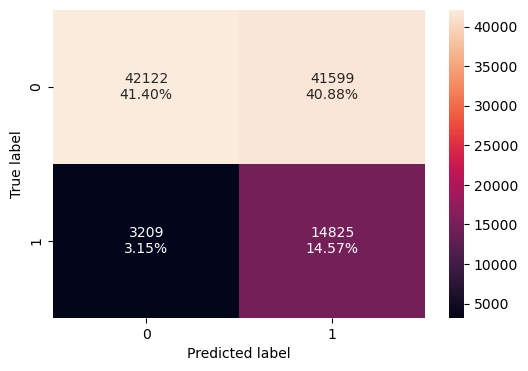

In [76]:
#Calculating different metrics
xgb_tuned_T2_model_train_perf=model_performance_classification_sklearn(xgb_tuned_T2,X_train,y_train)
print("Training performance:\n",xgb_tuned_T2_model_train_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T2,X_train,y_train)

Validation performance:
    Accuracy  Recall  Precision   F1
0      0.56    0.81       0.26 0.39


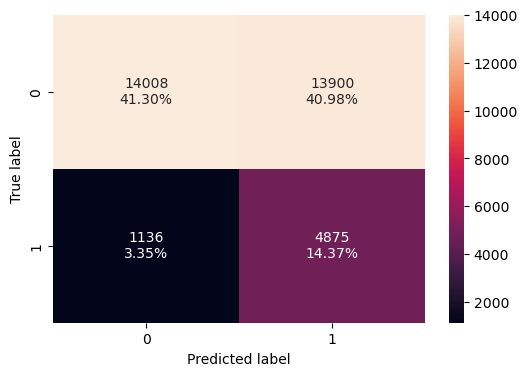

In [77]:
#Calculating different metrics
xgb_tuned_T2_model_val_perf=model_performance_classification_sklearn(xgb_tuned_T2,X_val,y_val)
print("Validation performance:\n",xgb_tuned_T2_model_val_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T2,X_val,y_val)

###### **Tier 3 tuning**

In [78]:
%%time
# Grid of parameters to choose from
parameters = {
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned_T2, parameters,scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned_T3 = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned_T3.fit(X_train, y_train)

CPU times: total: 55min 7s
Wall time: 5min 14s


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Training performance:
    Accuracy  Recall  Precision   F1
0      0.56    0.82       0.26 0.40


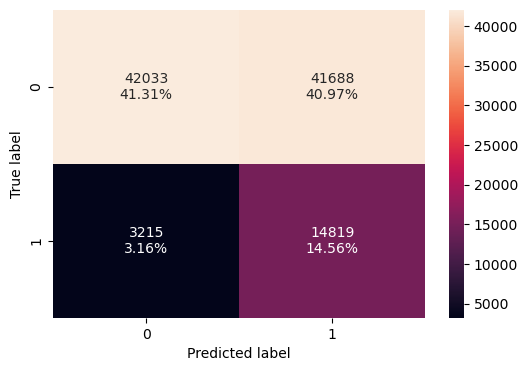

In [79]:
#Calculating different metrics
xgb_tuned_T3_model_train_perf=model_performance_classification_sklearn(xgb_tuned_T3,X_train,y_train)
print("Training performance:\n",xgb_tuned_T3_model_train_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3,X_train,y_train)

Validation performance:
    Accuracy  Recall  Precision   F1
0      0.56    0.81       0.26 0.39


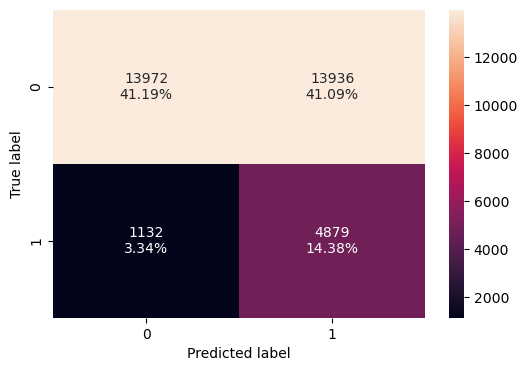

In [80]:
#Calculating different metrics
xgb_tuned_T3_model_val_perf=model_performance_classification_sklearn(xgb_tuned_T3,X_val,y_val)
print("Validation performance:\n",xgb_tuned_T3_model_val_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3,X_val,y_val)

##### **Find optimal threshold**

###### **ROC-AUC**

In [81]:
y_pred_prob_xgb = xgb_tuned_T3.predict_proba(X_train)[:,1]

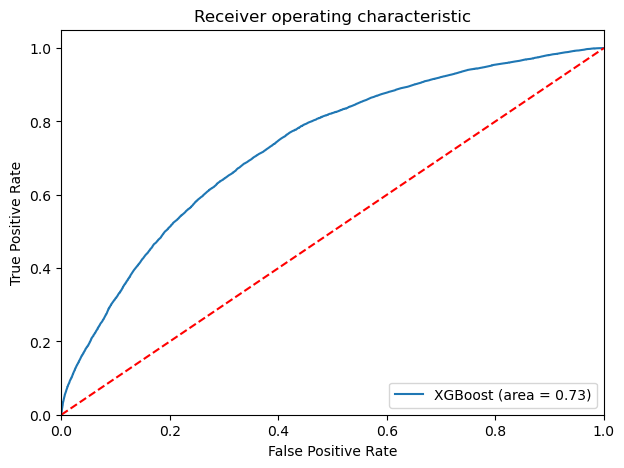

In [82]:
xgb_roc_auc_train = roc_auc_score(y_train,y_pred_prob_xgb)
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob_xgb)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="XGBoost (area = %0.2f)" % xgb_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [83]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, y_pred_prob_xgb)

optimal_idx = np.argmax(tpr - fpr)
xgb_optimal_threshold_auc_roc = thresholds[optimal_idx]
print(xgb_optimal_threshold_auc_roc)

0.531887412071228


###### **PR-curve**

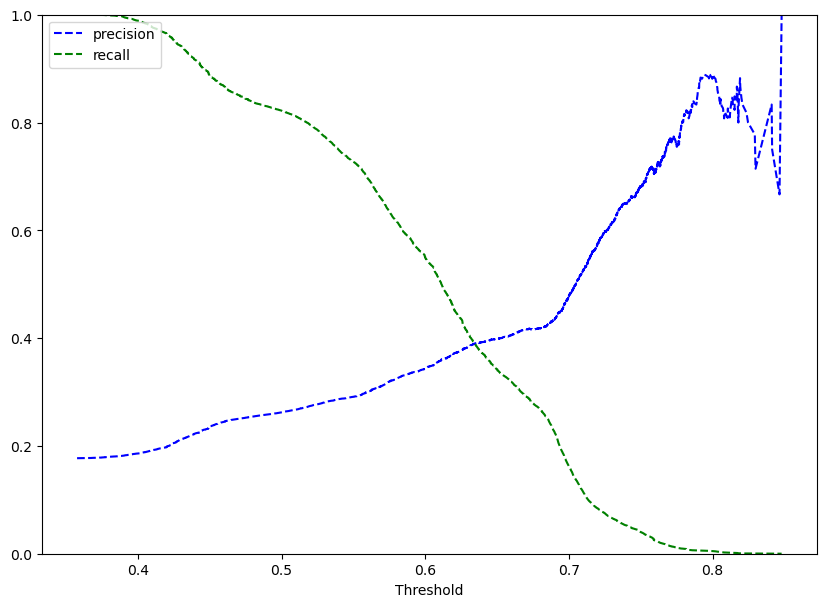

In [84]:
prec, rec, tre = precision_recall_curve(y_train, y_pred_prob_xgb)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [85]:
# searching the intersection point of recall and precision
print(intersection(rec.tolist(),prec.tolist()))
intersected = intersection(rec.tolist(),prec.tolist())

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8582677165354331, 0.8582677165354331, 0.8309859154929577, 0.8028169014084507, 0.8028169014084507, 0.8028169014084507, 0.8028169014084507, 0.7676056338028169, 0.7676056338028169, 0.7598425196850394, 0.7598425196850394, 0.7598425196850394, 0.7598425196850394, 0.7598425196850394, 0.7598425196850394, 0.7253521126760564, 0.7253521126760564, 0.7253521126760564, 0.7253521126760564, 0.7204724409448819, 0.7204724409448819, 0.7204724409448819, 0.7204724409448819, 0.6901408450704225, 0.6901408450704225, 0.6901408450704225, 0.6901408450704225, 0.6901408450704225, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.6619718309859155, 0.5704225352112676, 0.5704225352112676, 0.5704225352112676, 0.56

In [86]:
# extract the threshold 
intersect = pd.DataFrame({'prec': prec[:-1],
                          'rec': rec[:-1],
                          'tre': tre})

intersect[intersect['prec'] == 0.389985582788067]

,prec,rec,tre
26393,0.39,0.39,0.63


In [87]:
# setting the threshold
xgb_optimal_threshold_curve = 0.63

##### **Check training and validation performance with new threshold**

**Training**

Training performance:
    Accuracy  Recall  Precision   F1
0      0.61    0.77       0.28 0.41


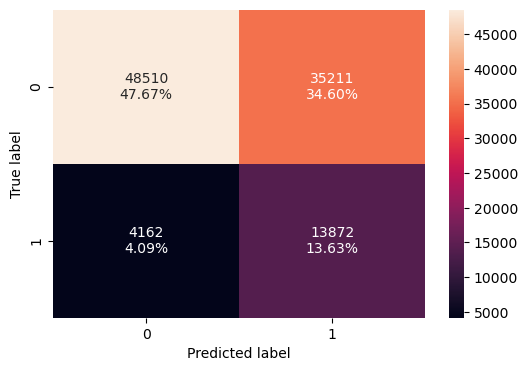

In [88]:
#Calculating different metrics
xgb_tuned_T3_model_train_perf_threshold_auc_roc=model_performance_classification_sklearn(
    xgb_tuned_T3, X_train, y_train, xgb_optimal_threshold_auc_roc)
print("Training performance:\n",xgb_tuned_T3_model_train_perf_threshold_auc_roc)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3, X_train, y_train, xgb_optimal_threshold_auc_roc)

Training performance:
    Accuracy  Recall  Precision   F1
0      0.78    0.41       0.38 0.40


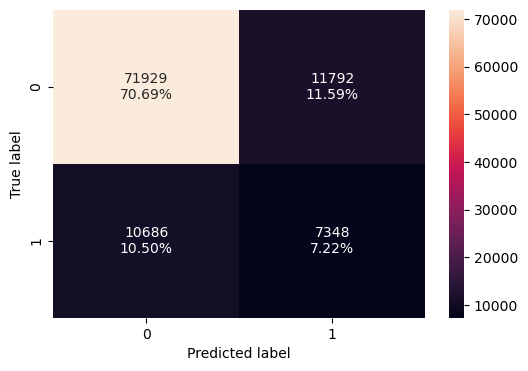

In [89]:
#Calculating different metrics
xgb_tuned_T3_model_train_perf_threshold_curve=model_performance_classification_sklearn(
    xgb_tuned_T3, X_train, y_train, xgb_optimal_threshold_curve)
print("Training performance:\n",xgb_tuned_T3_model_train_perf_threshold_curve)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3, X_train, y_train, xgb_optimal_threshold_curve)

**Validation**

Training performance:
    Accuracy  Recall  Precision   F1
0      0.61    0.75       0.28 0.41


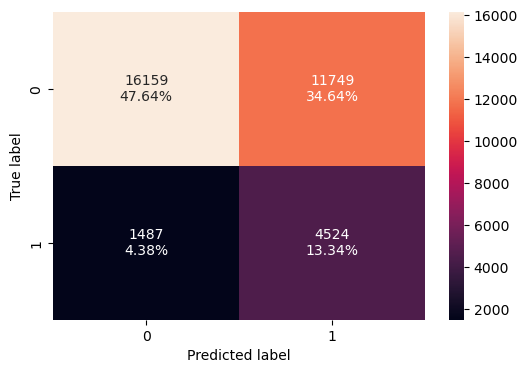

In [90]:
#Calculating different metrics
xgb_tuned_T3_model_val_perf_threshold_auc_roc=model_performance_classification_sklearn(
    xgb_tuned_T3, X_val, y_val, xgb_optimal_threshold_auc_roc)
print("Training performance:\n",xgb_tuned_T3_model_val_perf_threshold_auc_roc)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3, X_val, y_val, xgb_optimal_threshold_auc_roc)

Training performance:
    Accuracy  Recall  Precision   F1
0      0.78    0.41       0.38 0.39


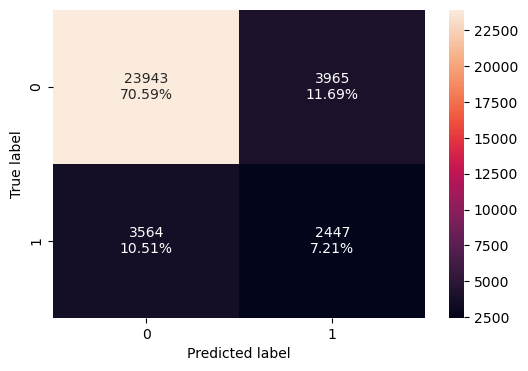

In [91]:
#Calculating different metrics
xgb_tuned_T3_model_val_perf_threshold_curve=model_performance_classification_sklearn(
    xgb_tuned_T3, X_val, y_val, xgb_optimal_threshold_curve)
print("Training performance:\n",xgb_tuned_T3_model_val_perf_threshold_curve)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3, X_val, y_val, xgb_optimal_threshold_curve)

##### **Compare result**

In [92]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        xgb_tuned_T3_model_train_perf.T,
        xgb_tuned_T3_model_train_perf_threshold_auc_roc.T,
        xgb_tuned_T3_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "XGBoost-default Threshold (0.5)",
    "XGBoost-0.53 Threshold",
    "XGBoost-0.63 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,XGBoost-default Threshold (0.5),XGBoost-0.53 Threshold,XGBoost-0.63 Threshold
Accuracy,0.56,0.61,0.78
Recall,0.82,0.77,0.41
Precision,0.26,0.28,0.38
F1,0.40,0.41,0.40


In [93]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        xgb_tuned_T3_model_val_perf.T,
        xgb_tuned_T3_model_val_perf_threshold_auc_roc.T,
        xgb_tuned_T3_model_val_perf_threshold_curve.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "XGBoost-default Threshold (0.5)",
    "XGBoost-0.53 Threshold",
    "XGBoost-0.63 Threshold",
]

print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,XGBoost-default Threshold (0.5),XGBoost-0.53 Threshold,XGBoost-0.63 Threshold
Accuracy,0.56,0.61,0.78
Recall,0.81,0.75,0.41
Precision,0.26,0.28,0.38
F1,0.39,0.41,0.39


#### Final model comparison

In [94]:
print('Area Under the logit ROC Curve for train set:', roc_auc_score(y_train, lr.predict_proba(X_train3)[:,1]))
print('Area Under the XGBoost ROC Curve for train set:', roc_auc_score(y_train, xgb_tuned_T3.predict_proba(X_train)[:,1]))

Area Under the logit ROC Curve for train set: 0.6722307755562114
Area Under the XGBoost ROC Curve for train set: 0.7326440687265197


In [95]:
print('Area Under the logit ROC Curve for validation set:', roc_auc_score(y_val, lr.predict_proba(X_val1)[:,1]))
print('Area Under the XGBoost ROC Curve for validation set:', roc_auc_score(y_val, xgb_tuned_T3.predict_proba(X_val)[:,1]))

Area Under the logit ROC Curve for validation set: 0.6777123938633646
Area Under the XGBoost ROC Curve for validation set: 0.7266698144319857


In [96]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        xgb_tuned_T3_model_train_perf_threshold_auc_roc.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "XGBoost-0.53 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold (0.5),XGBoost-0.53 Threshold
Accuracy,0.64,0.61
Recall,0.60,0.77
Precision,0.27,0.28
F1,0.37,0.41


In [97]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        log_reg_model_val_perf.T,
        xgb_tuned_T3_model_val_perf_threshold_auc_roc.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "XGBoost-0.53 Threshold",
]

print("Validation set performance comparison:")
models_val_comp_df

Validation set performance comparison:


,Logistic Regression-default Threshold (0.5),XGBoost-0.53 Threshold
Accuracy,0.64,0.61
Recall,0.61,0.75
Precision,0.27,0.28
F1,0.38,0.41


#### Test set performance

##### Logit model with default threshold

In [98]:
X_test1 = X_test[list(X_train3.columns)]

Test performance:
    Accuracy  Recall  Precision   F1
0      0.64    0.60       0.27 0.37


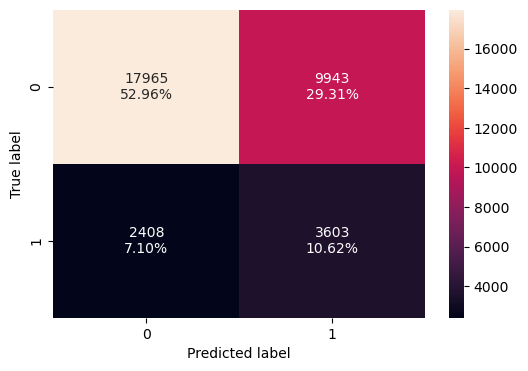

In [99]:
# Calculating different metrics on test set
log_reg_model_test_perf = model_performance_classification_sklearn(lr, X_test1, y_test)
print("Test performance:\n",log_reg_model_test_perf)

# creating confusion matrix
confusion_matrix_sklearn(lr, X_test1, y_test)

##### XGBoost model with 0.53 threshold

Test performance:
    Accuracy  Recall  Precision   F1
0      0.61    0.75       0.28 0.41


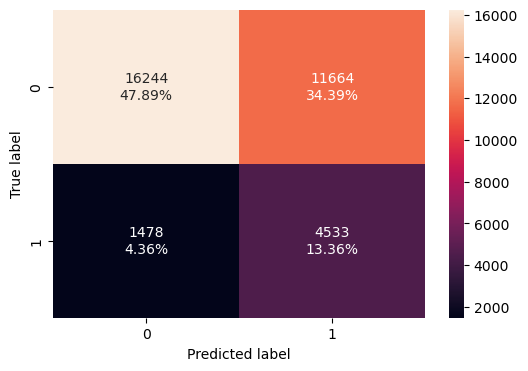

In [100]:
#Calculating different metrics
xgb_tuned_T3_model_test_perf_threshold_auc_roc=model_performance_classification_sklearn(
    xgb_tuned_T3, X_test, y_test, xgb_optimal_threshold_auc_roc)
print("Test performance:\n",xgb_tuned_T3_model_test_perf_threshold_auc_roc)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_tuned_T3, X_test, y_test, xgb_optimal_threshold_auc_roc)

##### ROC_AUC_score

In [101]:
p_hat_logit = lr.predict_proba(X_test1)[:,1]
p_hat_xgb = xgb_tuned_T3.predict_proba(X_test)[:,1]

print('Area Under the logit ROC Curve for test set:', roc_auc_score(y_test, p_hat_logit))
print('Area Under the XGBoost ROC Curve for test set:', roc_auc_score(y_test, p_hat_xgb))

Area Under the logit ROC Curve for test set: 0.6689229145305653
Area Under the XGBoost ROC Curve for test set: 0.7280162900431909


We proceed the remaining analysis using logit model with default threshold, and xgboost model with 0.53 threshold.

## Lift analysis

### Data preperation

In [102]:
p_hat_logit = pd.DataFrame(p_hat_logit,columns=['p_logit'])
p_hat_xgb = pd.DataFrame(p_hat_xgb,columns=['p_xgb'])

In [103]:
y_test = y_test.reset_index(drop=True)

**Create dataframe**

In [104]:
lift_analysis_df = pd.concat(
    [
        id_test,
        y_test,
        p_hat_logit,
        p_hat_xgb,
    ],
    axis=1,
)

lift_analysis_df.columns = [
    "unique_id",
    "y_true",
    "p_logit",
    "p_xgb",
]

In [105]:
lift_analysis_df

,unique_id,y_true,p_logit,p_xgb
0,99563,0,0.47,0.43
1,6937,0,0.44,0.43
2,37165,0,0.33,0.60
3,61874,0,0.37,0.58
4,146310,0,0.67,0.48
...,...,...,...,...
33914,64606,0,0.42,0.42
33915,140466,0,0.38,0.42
33916,49135,0,0.46,0.44
33917,92727,0,0.47,0.43


### Model effectiveness

#### XGBoost probabilities

In [106]:
# sort dataframe
lift_analysis_df1 = lift_analysis_df.sort_values(by='p_xgb', ascending=False).reset_index(drop=True)

# add decile column
lift_analysis_df1["decile"] = pd.qcut(lift_analysis_df1.index, 10, labels=False, duplicates='drop') + 1

In [107]:
lift_analysis_df1

,unique_id,y_true,p_logit,p_xgb,decile
0,141854,0,0.87,0.82,1
1,21247,1,0.83,0.82,1
2,72079,1,0.85,0.82,1
3,36216,1,0.83,0.82,1
4,121574,1,0.82,0.82,1
...,...,...,...,...,...
33914,164487,0,0.21,0.36,10
33915,117236,0,0.16,0.36,10
33916,95568,0,0.17,0.36,10
33917,36167,0,0.25,0.36,10


In [108]:
# aggregate metric per decile
lift_table_xgb = lift_analysis_df1.groupby("decile").agg(
    customers = ('y_true', 'count'),
    churners = ('y_true', 'sum')   # Positive response using XGB
)

# churn rate using XGB
lift_table_xgb["churn_rate"] = lift_table_xgb["churners"] / lift_table_xgb["customers"]

# cummulative positive response using XGB
lift_table_xgb["cum_customers"] = lift_table_xgb["customers"].cumsum()
lift_table_xgb["cum_churners"]  = lift_table_xgb["churners"].cumsum()

# cummulative sum
total_customers = lift_table_xgb["customers"].sum()
total_churners  = lift_table_xgb["churners"].sum()

# cummulative percentage
lift_table_xgb["cum_customer_pct"] = lift_table_xgb["cum_customers"] / total_customers

# gain
lift_table_xgb["gain"]    = lift_table_xgb["cum_churners"] / total_churners

# overall churn rate, without a model, fix rate over all decile.
overall_churn_rate = total_churners / total_customers

# lift per decile
lift_table_xgb["lift"] = lift_table_xgb["churn_rate"] / overall_churn_rate

# cumulative lift
lift_table_xgb["cum_lift"] = lift_table_xgb["gain"] / lift_table_xgb["cum_customer_pct"]

In [109]:
lift_table_xgb

,customers,churners,churn_rate,cum_customers,cum_churners,cum_customer_pct,gain,lift,cum_lift
decile,,,,,,,,,
1,3392,1449,0.43,3392,1449,0.10,0.24,2.41,2.41
2,3392,1136,0.33,6784,2585,0.20,0.43,1.89,2.15
3,3392,835,0.25,10176,3420,0.30,0.57,1.39,1.90
4,3392,656,0.19,13568,4076,0.40,0.68,1.09,1.70
5,3392,573,0.17,16960,4649,0.50,0.77,0.95,1.55
6,3391,443,0.13,20351,5092,0.60,0.85,0.74,1.41
7,3392,292,0.09,23743,5384,0.70,0.90,0.49,1.28
8,3392,270,0.08,27135,5654,0.80,0.94,0.45,1.18
9,3392,215,0.06,30527,5869,0.90,0.98,0.36,1.08


In [110]:
top_decile_lift_xgb = lift_table_xgb.iloc[0]["lift"]
top_decile_lift_xgb

np.float64(2.4105095355841333)

Top 10% customers are 2.41x more likely to churn vs average.

#### Logit probabilities

In [111]:
# sort dataframe
lift_analysis_df2 = lift_analysis_df.sort_values(by='p_logit', ascending=False).reset_index(drop=True)

# add decile column
lift_analysis_df2["decile"] = pd.qcut(lift_analysis_df2.index, 10, labels=False, duplicates='drop') + 1

In [112]:
lift_analysis_df2

,unique_id,y_true,p_logit,p_xgb,decile
0,11923,0,0.91,0.76,1
1,42813,0,0.91,0.73,1
2,19635,0,0.90,0.72,1
3,155543,1,0.89,0.77,1
4,59362,1,0.89,0.77,1
...,...,...,...,...,...
33914,68324,0,0.14,0.36,10
33915,147740,0,0.14,0.52,10
33916,144641,0,0.13,0.48,10
33917,115771,0,0.13,0.56,10


In [113]:
# aggregate metric per decile
lift_table_lg = lift_analysis_df2.groupby("decile").agg(
    customers = ('y_true', 'count'),
    churners = ('y_true', 'sum')        # Positive response using XGB
)

# churn rate using XGB
lift_table_lg["churn_rate"] = lift_table_lg["churners"] / lift_table_lg["customers"]

# cummulative positive response using XGB
lift_table_lg["cum_customers"] = lift_table_lg["customers"].cumsum()
lift_table_lg["cum_churners"]  = lift_table_lg["churners"].cumsum()

# cummulative sum
total_customers = lift_table_lg["customers"].sum()
total_churners  = lift_table_lg["churners"].sum()

# cummulative percentage
lift_table_lg["cum_customer_pct"] = lift_table_lg["cum_customers"] / total_customers

# gain
lift_table_lg["gain"]    = lift_table_lg["cum_churners"] / total_churners

# # overall churn rate, without a model, fix rate over all decile.
overall_churn_rate = total_churners / total_customers

# lift per decile
lift_table_lg["lift"] = lift_table_lg["churn_rate"] / overall_churn_rate

# cumulative lift
lift_table_lg["cum_lift"] = lift_table_lg["gain"] / lift_table_lg["cum_customer_pct"]

In [114]:
lift_table_lg

,customers,churners,churn_rate,cum_customers,cum_churners,cum_customer_pct,gain,lift,cum_lift
decile,,,,,,,,,
1,3392,1260,0.37,3392,1260,0.10,0.21,2.10,2.10
2,3392,947,0.28,6784,2207,0.20,0.37,1.58,1.84
3,3392,737,0.22,10176,2944,0.30,0.49,1.23,1.63
4,3392,665,0.20,13568,3609,0.40,0.60,1.11,1.50
5,3392,571,0.17,16960,4180,0.50,0.70,0.95,1.39
6,3391,490,0.14,20351,4670,0.60,0.78,0.82,1.29
7,3392,445,0.13,23743,5115,0.70,0.85,0.74,1.22
8,3392,393,0.12,27135,5508,0.80,0.92,0.65,1.15
9,3392,308,0.09,30527,5816,0.90,0.97,0.51,1.08


In [115]:
top_decile_lift_lg = lift_table_lg.iloc[0]["lift"]
top_decile_lift_lg

np.float64(2.096095248334029)

Top 10% customers are 2.10x more likely to churn vs average.

#### Plots

**Gain curve**

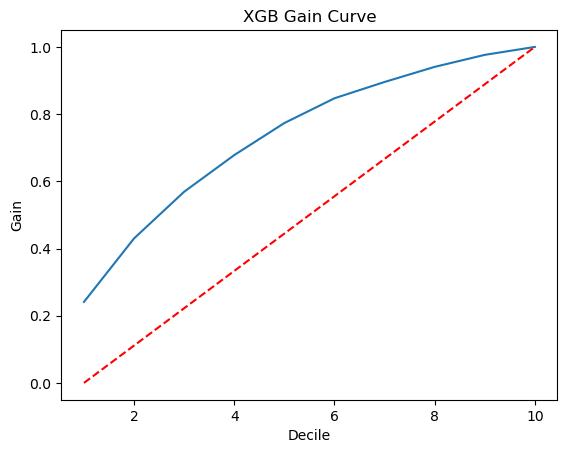

In [116]:
plt.plot(lift_table_xgb["gain"])
plt.plot([1,10],[0,1], "r--")
plt.xlabel("Decile")
plt.ylabel("Gain")
plt.title("XGB Gain Curve")
plt.show()

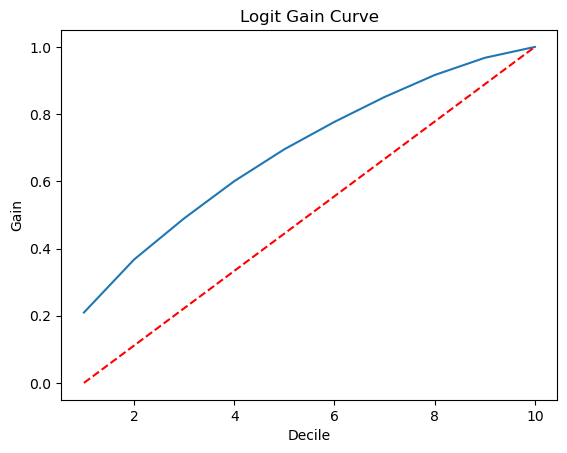

In [117]:
plt.plot(lift_table_lg["gain"])
plt.plot([1,10],[0,1], "r--")
plt.xlabel("Decile")
plt.ylabel("Gain")
plt.title("Logit Gain Curve")
plt.show()

**Lift curve**

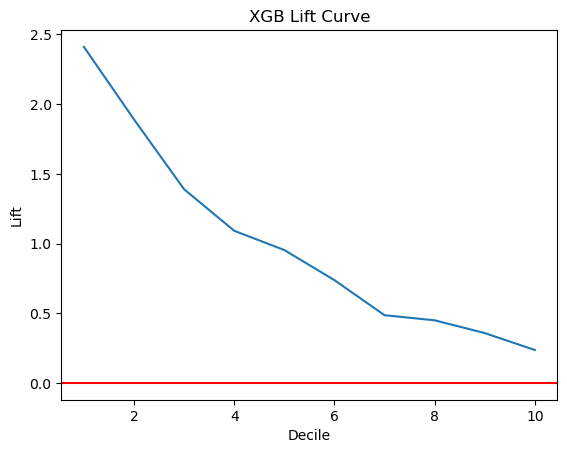

In [118]:
plt.plot(lift_table_xgb["lift"])
plt.axhline(0, c='r')
plt.xlabel("Decile")
plt.ylabel("Lift")
plt.title("XGB Lift Curve")
plt.show()

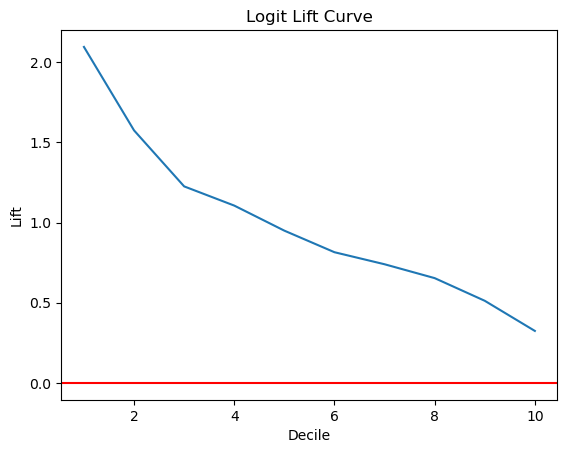

In [119]:
plt.plot(lift_table_lg["lift"])
plt.axhline(0, c='r')
plt.xlabel("Decile")
plt.ylabel("Lift")
plt.title("Logit Lift Curve")
plt.show()

## Profit optimization

**Define business parameters**

In [120]:
CLV = 1000             # value retained if churn prevented
Cost = 170              # intervention cost per customer
Success_rate = 0.3    # probability intervention prevents churn

#### XGBoost probability

In [121]:
# expected profit 
lift_analysis_df1["expected_profit"] = (
    lift_analysis_df1["p_xgb"] * Success_rate * CLV
) - Cost

# cumulative profit
lift_analysis_df1["cum_profit"] = lift_analysis_df1["expected_profit"].cumsum()

# percentage of customers targeted
lift_analysis_df1["customer_count"] = np.arange(1, len(lift_analysis_df1)+1)
lift_analysis_df1["target_pct"] = lift_analysis_df1["customer_count"] / len(lift_analysis_df1)

# find optimal targeting point
optimal_row_xgb = lift_analysis_df1.loc[lift_analysis_df1["cum_profit"].idxmax()]
optimal_pct    = optimal_row_xgb["target_pct"]
max_profit     = optimal_row_xgb["cum_profit"]
optimal_cutoff = optimal_row_xgb["p_xgb"]

print("Optimal targeting %:", optimal_pct)
print("Maximum profit:", max_profit)
print("Probability cutoff:", optimal_cutoff)

# Step 7: mark targets
lift_analysis_df1["target"] = lift_analysis_df1["p_xgb"] >= optimal_cutoff

# Step 8: extract final targeting list
xgb_df_target = lift_analysis_df1[lift_analysis_df1["target"] == True]

Optimal targeting %: 0.3824110380612636
Maximum profit: 291117.96875
Probability cutoff: 0.5667533278465271


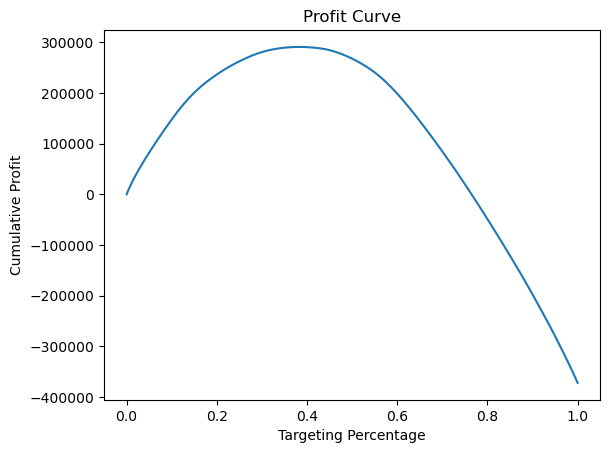

In [122]:
plt.plot(lift_analysis_df1["target_pct"], lift_analysis_df1["cum_profit"])
plt.xlabel("Targeting Percentage")
plt.ylabel("Cumulative Profit")
plt.title("Profit Curve")
plt.show()

#### Logit probability

In [123]:
# expected profit 
lift_analysis_df2["expected_profit"] = (
    lift_analysis_df2["p_xgb"] * Success_rate * CLV
) - Cost

# cumulative profit
lift_analysis_df2["cum_profit"] = lift_analysis_df2["expected_profit"].cumsum()

# percentage of customers targeted
lift_analysis_df2["customer_count"] = np.arange(1, len(lift_analysis_df2)+1)
lift_analysis_df2["target_pct"] = lift_analysis_df2["customer_count"] / len(lift_analysis_df2)

# find optimal targeting point
optimal_row_lg = lift_analysis_df2.loc[lift_analysis_df2["cum_profit"].idxmax()]
optimal_pct    = optimal_row_lg["target_pct"]
max_profit     = optimal_row_lg["cum_profit"]
optimal_cutoff = optimal_row_lg["p_xgb"]

print("Optimal targeting %:", optimal_pct)
print("Maximum profit:", max_profit)
print("Probability cutoff:", optimal_cutoff)

# Step 7: mark targets
lift_analysis_df2["target"] = lift_analysis_df2["p_xgb"] >= optimal_cutoff

# Step 8: extract final targeting list
lg_df_target = lift_analysis_df2[lift_analysis_df2["target"] == True]

Optimal targeting %: 0.2276894955629588
Maximum profit: 143022.484375
Probability cutoff: 0.6064845323562622


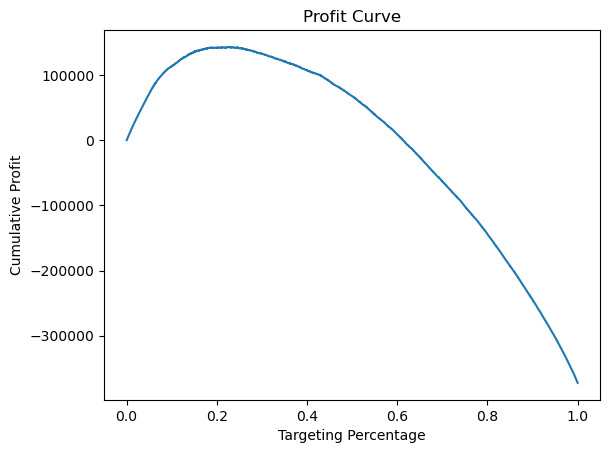

In [124]:
plt.plot(lift_analysis_df2["target_pct"], lift_analysis_df2["cum_profit"])
plt.xlabel("Targeting Percentage")
plt.ylabel("Cumulative Profit")
plt.title("Profit Curve")
plt.show()

# Business insights and Recommendation

- Our XGBoost model outperforms the Logistic Regression model.
- XGBoost generates 2 times more profit:
$$ \frac{291,117}{143,022} = 2.03 $$
- XGBoost identifies more profitable customers, which enables scaling retention campaigns safely.
- Top 10% highest-risk customers are 2.41× more likely to churn than average, under XGBoost model. Marketing efficiency improves by 141\%.
- Higher recall score of 75%, capturing more churners.
- By targeting the top 38% highest-risk customers identified by the model, the bank can maximize retention profit while optimizing marketing resource allocation.